# NB02 - SFLLD Exploratory Data Analysis

---

## Purpose

This notebook performs a full exploratory data analysis on the Parquet files produced by NB01. Its role in the pipeline is threefold:

1. **Data validation** - verifies structural integrity, sentinel handling, and disclosure-era semantics of the raw SFLLD data before any modelling takes place.
2. **Feature documentation** - establishes the empirical justification for NB03 feature engineering decisions, including which fields are hard-excluded from the model and why.
3. **Thesis-specific diagnostics** - provides the empirical groundwork for both levels of the thesis's two-level failure taxonomy: the rare-event positive rate that drives Level 1 intrinsic CP failures, and the distributional shift evidence that motivates Level 2 regime-specific failures.

---

## Dataset and Problem Scope

**Dataset:** As described in NB01.

**Thesis panel scope:** NB03 processes origination vintages 1999-2023 only. Release 46 contains 2024-2025 originations; these are described where relevant but fall outside the modelling window.

**Modelling target:** The thesis is framed as a **discrete-time transition-risk problem** (active current/30-DPD loans transitioning to 60+ DPD or REO Acquisition within 12 months). Full definition and terminology rules are given in §0.4.

---

## Notebook Structure

| Section | Content | Pipeline relevance |
|---|---|---|
| **0** | Setup, DuckDB connection, canonical target semantics | Defines `POS_CLASS`, `DQ60_ONLY`, `REO_ACQ` used throughout |
| **1** | Dataset structural validation | Join integrity, key uniqueness, row-count parity |
| **2** | Origination data quality | Sentinel/range compliance (FICO, LTV, CLTV, DTI); disclosure-era semantics for `channel`, `number_of_borrowers`, `modification_flag`, `payment_deferral_flag`, `property_valuation_method`; hard-exclusion justifications |
| **3** | Performance panel characteristics | Delinquency code audit, ZBC distribution, lifetime event flags, anomaly detection |
| **4** | Vintage-level analysis | Origination volume and underwriting trends 1999-2023; DTI=999 vintage interpretation |
| **5.1-5.4** | Thesis motivation + CP feasibility | Monthly distress time series; vintage delinquency curves; COVID forbearance diagnostics; Mondrian calibration-window positive-class cell counts |
| **5.5-5.7** | Calibration window size and contamination; forward-looking class imbalance; geographic coverage |
| **5.8-5.10** | Distributional shift evidence | FICO×LTV subgroup rates by regime; PSI covariate shift (numeric + categorical); bucket-level risk monotonicity |
| **5.11-5.12** | Feature design diagnostics | ELTV availability; prepayment rate by regime |

---

## Key Design Notes

- **Hard-excluded model features** are consolidated in §3.1. They are retained in the NB03 panel schema for diagnostics but never promoted to active model inputs.
- **`test_normal`** ends 2019-09-30.
- **PSI in §5.9** is feature-level covariate PSI. It is a different quantity from the score-distribution PSI in NB07 and the two can be directionally opposite for the same regime.
- **Regime gap periods** (Oct 2019-Feb 2020; Oct-Dec 2021) exist intentionally as contamination buffers between panel splits. Loan-months in these gaps are not assigned to any split.

---
## Section 0 · Setup & Configuration

### 0.1 · Install Dependencies

In [ ]:
%pip install -q duckdb pyarrow pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 165.9 MB/s eta 0:00:00


### 0.2 · Imports

In [ ]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 4)})

IS_COLAB = "google.colab" in sys.modules or Path("/content").exists()
print(f"Python {sys.version.split()[0]}")

Python 3.12.13


### 0.3 · Google Drive Mount & Path Configuration


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
DRIVE_ROOT = Path("/content/drive/MyDrive/master_thesis")

PARQUET_ROOT              = DRIVE_ROOT / "data" / "parquet"
MANIFEST_DIR = DRIVE_ROOT / "manifests"
ORIGINATION_OUT           = PARQUET_ROOT / "origination"
PERFORMANCE_OUT           = PARQUET_ROOT / "performance"
PERFORMANCE_BY_PERIOD_OUT = PARQUET_ROOT / "performance_by_period"

DUCKDB_TEMP_DIR = "/content/duckdb_tmp" if IS_COLAB else str(DRIVE_ROOT / "duckdb_tmp")
Path(DUCKDB_TEMP_DIR).mkdir(parents=True, exist_ok=True)

orig_glob        = (ORIGINATION_OUT           / "**" / "*.parquet").as_posix()
perf_glob        = (PERFORMANCE_OUT           / "**" / "*.parquet").as_posix()
perf_period_glob = (PERFORMANCE_BY_PERIOD_OUT / "**" / "*.parquet").as_posix()

for p, name in [
    (ORIGINATION_OUT,           "origination"),
    (PERFORMANCE_OUT,           "performance (vintage)"),
    (PERFORMANCE_BY_PERIOD_OUT, "performance (by period)"),
]:
    status = "✓" if p.exists() else "✗ MISSING - run 01_data_preparation.ipynb first."
    print(f"  {status}  {name}: {p}")

Mounted at /content/drive
  ✓  origination: /content/drive/MyDrive/master_thesis/data/parquet/origination
  ✓  performance (vintage): /content/drive/MyDrive/master_thesis/data/parquet/performance
  ✓  performance (by period): /content/drive/MyDrive/master_thesis/data/parquet/performance_by_period


### 0.4 · DuckDB Connection & Views

| View | Partition | Best for |
|---|---|---|
| `sf_origination` | vintage | All origination queries |
| `sf_performance` | vintage | Lifetime / aggregate queries |
| `sf_performance_by_period` | reporting year | Time-windowed regime queries |

**Partition columns:** DuckDB injects `vintage_year` and `vintage_quarter` as Hive-style partition columns when reading NB01's directory structure (`vintage_year=YYYY/vintage_quarter=QN`). Queries in this notebook use these columns directly. NB03 §1.2 re-derives the same values from `loan_sequence_number` under the names `true_vintage_year` / `true_vintage_quarter` to make the derivation source unambiguous; the values are equivalent.

**String field trimming:** NB01 applies `NULLIF(TRIM(expr), '')` to all string fields during ingestion via its `trim_sql()` helper. The `TRIM()` calls in several queries below are therefore redundant but kept for defensive clarity.


In [ ]:
N_THREADS    = min(40, max(1, (os.cpu_count() or 4) - 4))
MEMORY_LIMIT = "160GB"

def connect_duckdb() -> duckdb.DuckDBPyConnection:
    con = duckdb.connect()
    con.execute(f"SET threads        = {N_THREADS}")
    con.execute(f"SET memory_limit   = '{MEMORY_LIMIT}'")
    con.execute(f"SET temp_directory = '{DUCKDB_TEMP_DIR}'")
    con.execute("SET enable_progress_bar = true")
    return con

con = connect_duckdb()
con.execute(f"CREATE OR REPLACE VIEW sf_origination           AS SELECT * FROM read_parquet('{orig_glob}',        union_by_name=True)")
con.execute(f"CREATE OR REPLACE VIEW sf_performance           AS SELECT * FROM read_parquet('{perf_glob}',        union_by_name=True)")
con.execute(f"CREATE OR REPLACE VIEW sf_performance_by_period AS SELECT * FROM read_parquet('{perf_period_glob}', union_by_name=True)")

print(f"DuckDB {duckdb.__version__}  |  {N_THREADS} threads  |  {MEMORY_LIMIT}")

# Target definitions - see markdown cell below for full rationale
DQ60_ONLY = "TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 2"
REO_ACQ   = "current_loan_delinquency_status IN ('RA', 'R')"
POS_CLASS = f"({DQ60_ONLY}) OR ({REO_ACQ})"

print("\nCanonical conditions")
print(f"  DQ60_ONLY : {DQ60_ONLY}")
print(f"  REO_ACQ   : {REO_ACQ}")
print(f"  POS_CLASS : {POS_CLASS}")

# Helper for joined queries where the performance table carries an alias
def pos_class_for(alias: str) -> str:
    return POS_CLASS.replace("current_loan_delinquency_status", f"{alias}.current_loan_delinquency_status")

POS_CLASS_P = pos_class_for("p")
print(f"  POS_CLASS_P : {POS_CLASS_P}")

DuckDB 1.5.4  |  40 threads  |  160GB

Canonical conditions
  DQ60_ONLY : TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 2
  REO_ACQ   : current_loan_delinquency_status IN ('RA', 'R')
  POS_CLASS : (TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 2) OR (current_loan_delinquency_status IN ('RA', 'R'))
  POS_CLASS_P : (TRY_CAST(p.current_loan_delinquency_status AS INTEGER) >= 2) OR (p.current_loan_delinquency_status IN ('RA', 'R'))


#### Canonical target semantics used throughout the notebook

This notebook distinguishes between two related but non-identical event definitions:

- **`DQ60_ONLY`**: contemporaneous strict delinquency state, defined as numeric status `>= 2`
- **`POS_CLASS`**: contemporaneous target-event condition, defined as **60+ DPD or REO Acquisition**

This distinction is necessary because Freddie Mac's `current_loan_delinquency_status`
contains two different semantic families:

1. **numeric delinquency buckets** (`0`, `1`, `2`, `3`, ...)
2. **REO-acquisition servicing-state codes** (`RA`, legacy `R`)

`RA` / `R` are **not** delinquency buckets. They indicate that the loan has already entered
the REO process after foreclosure completion. For descriptive EDA, terminology must therefore remain explicit:

- use **"60+ DPD"** only for `DQ60_ONLY`
- use **"60+ DPD or REO Acquisition"** for `POS_CLASS`

**Downstream modeling scope:** `y = 1` is the **forward positive class**: an eligible
current/30-DPD observation has `POS_CLASS` occur within `(t, t+12]`.

That means the thesis problem is a **transition-risk** problem:
from **current / early-stage delinquency** into **material distress**.

### 0.5 · Release Metadata Verification

In [ ]:
manifest_path = MANIFEST_DIR / "ingestion_manifest.json"
if manifest_path.exists():
    with open(manifest_path) as fh:
        INGESTION_MANIFEST = json.load(fh)
    print("✓  Ingestion manifest found:")
    for k in ["release_number","release_date","origination_cutoff_date",
               "performance_cutoff_date","total_origination_rows","total_performance_rows"]:
        print(f"  {k:<45}: {INGESTION_MANIFEST.get(k,'N/A')}")
else:
    print("⚠  ingestion_manifest.json not found - run 01_data_preparation.ipynb first.")
    INGESTION_MANIFEST = {}

✓  Ingestion manifest found:
  release_number                               : 46
  release_date                                 : 2026-01-28
  origination_cutoff_date                      : 2025-09-30
  performance_cutoff_date                      : 2025-09-30
  total_origination_rows                       : 48597637
  total_performance_rows                       : 2800558227


### 0.6 · Row Count Sanity Check

In [ ]:
orig_count   = con.execute("SELECT COUNT(*) FROM sf_origination").fetchone()[0]
perf_count   = con.execute("SELECT COUNT(*) FROM sf_performance").fetchone()[0]
period_count = con.execute("SELECT COUNT(*) FROM sf_performance_by_period").fetchone()[0]

print(f"Origination rows              : {orig_count:>15,}")
print(f"Performance rows (vintage)    : {perf_count:>15,}")
print(f"Performance rows (by period)  : {period_count:>15,}")

if perf_count != period_count:
    print("⚠  Vintage and period row counts differ - repartition incomplete. ")
else:
    print("✓  Vintage and period row counts match.")

Origination rows              :      48,597,637
Performance rows (vintage)    :   2,800,558,227
Performance rows (by period)  :   2,800,558,227
✓  Vintage and period row counts match.


---
## Section 1 · Dataset Structure Validation

### 1.1 · Origination-Performance Join Integrity

Validates the core one-to-many relationship:
- one origination record per `loan_sequence_number`
- zero or more performance records per `loan_sequence_number`
- no orphaned performance records (performance without origination match)


In [ ]:
structural = con.execute("""
WITH
orig_stats AS (
    SELECT COUNT(*) AS n_orig_rows,
           COUNT(DISTINCT loan_sequence_number) AS n_orig_loans
    FROM sf_origination
),
perf_stats AS (
    SELECT COUNT(*) AS n_perf_rows,
           COUNT(DISTINCT loan_sequence_number) AS n_perf_loans
    FROM sf_performance
),
perf_ids AS (SELECT DISTINCT loan_sequence_number FROM sf_performance),
orig_without_perf AS (
    SELECT COUNT(*) AS n_orig_without_perf
    FROM sf_origination o
    LEFT JOIN perf_ids p USING (loan_sequence_number)
    WHERE p.loan_sequence_number IS NULL
),
perf_without_orig AS (
    SELECT COUNT(*) AS n_perf_without_orig
    FROM perf_ids p
    LEFT JOIN sf_origination o USING (loan_sequence_number)
    WHERE o.loan_sequence_number IS NULL
)
SELECT * FROM orig_stats, perf_stats, orig_without_perf, perf_without_orig
""").df()

print("=== Structural dataset contract ===")
display(structural.T.rename(columns={0: "value"}))

n_perf_without_orig = int(structural.loc[0, "n_perf_without_orig"])
n_orig_without_perf = int(structural.loc[0, "n_orig_without_perf"])

if n_orig_without_perf > 0:
    print(f"\nNote: {n_orig_without_perf:,} origination loans have no performance history.")

assert n_perf_without_orig == 0, (
    f"Found {n_perf_without_orig:,} orphaned performance records - investigate."
)
print("✓  No orphaned performance records.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Structural dataset contract ===


,value
n_orig_rows,48597637
n_orig_loans,48597637
n_perf_rows,2800558227
n_perf_loans,48597636
n_orig_without_perf,1
n_perf_without_orig,0



Note: 1 origination loans have no performance history.
✓  No orphaned performance records.


### 1.2 · Key Uniqueness Checks

In [ ]:
key_uniqueness = con.execute("""
WITH
orig_key_check AS (
    SELECT COUNT(*) AS total_orig_rows,
           COUNT(DISTINCT loan_sequence_number) AS distinct_orig_loans,
           COUNT(*) - COUNT(DISTINCT loan_sequence_number) AS duplicate_orig_rows
    FROM sf_origination
),
perf_key_check AS (
    SELECT COUNT(*) AS total_perf_rows,
           COUNT(DISTINCT (loan_sequence_number, monthly_reporting_period)) AS distinct_loan_month_keys,
           COUNT(*) - COUNT(DISTINCT (loan_sequence_number, monthly_reporting_period)) AS duplicate_perf_loan_month_rows
    FROM sf_performance
)
SELECT * FROM orig_key_check, perf_key_check
""").df()

print("=== Key uniqueness checks ===")
display(key_uniqueness.T.rename(columns={0: "value"}))

assert int(key_uniqueness.loc[0, "duplicate_orig_rows"]) == 0, "Duplicate origination keys found."
assert int(key_uniqueness.loc[0, "duplicate_perf_loan_month_rows"]) == 0, "Duplicate performance (loan,month) keys."
print("✓  Origination keys unique.")
print("✓  Performance (loan, month) keys unique.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Key uniqueness checks ===


,value
total_orig_rows,48597637
distinct_orig_loans,48597637
duplicate_orig_rows,0
total_perf_rows,2800558227
distinct_loan_month_keys,2800558227
duplicate_perf_loan_month_rows,0


✓  Origination keys unique.
✓  Performance (loan, month) keys unique.


---
## Section 2 · Origination Characteristics

### 2.1 · Key Variable Missingness & Range

For the key origination variables below, Freddie Mac uses documented numeric
sentinels for important non-observed states, so raw SQL-NULL rates alone
understate effective missingness. The query treats those sentinels as missing.

**Sentinel reference:**

| Variable | Sentinel | Meaning |
|---|---|---|
| `credit_score` | `9999` | FICO not available |
| `original_loan_to_value` | `999` | LTV not available |
| `original_combined_loan_to_value` | `999` | CLTV not available |
| `original_debt_to_income_ratio` | `999` | DTI > 65% *or* genuinely unknown *or* Relief Refinance loan - see §2.6 |
| `mortgage_insurance_percentage` | `999` | MI % not available |

Methodologically, these sentinels should be treated as **structured missingness / disclosure-rule encodings**, not as ordinary numeric values. This matters because the consequences of missingness depend on the mechanism generating the missing values; treating a disclosure-rule sentinel as random measurement noise would blur the distinction between unavailable, top-coded, structurally inapplicable, and policy-masked observations (Rubin, 1976; Little & Rubin, 2019). The Freddie Mac documentation defines the specific sentinel meanings; the missing-data literature provides the general reason why the mechanism matters for downstream inference and modelling.


In [ ]:
missingness = con.execute("""
SELECT * FROM (

    SELECT 'credit_score' AS variable,
           COUNT(*) AS n,
           SUM(CASE WHEN credit_score IS NULL OR credit_score = 9999 THEN 1 ELSE 0 END) AS n_missing,
           ROUND(100.0 * AVG(CASE WHEN credit_score IS NULL OR credit_score = 9999 THEN 1.0 ELSE 0.0 END), 4) AS pct_missing,
           MIN(CASE WHEN credit_score IS NOT NULL AND credit_score != 9999 THEN credit_score END) AS min_val,
           MAX(CASE WHEN credit_score IS NOT NULL AND credit_score != 9999 THEN credit_score END) AS max_val
    FROM sf_origination

    UNION ALL

    SELECT 'original_ltv', COUNT(*),
           SUM(CASE WHEN original_loan_to_value IS NULL OR original_loan_to_value = 999 THEN 1 ELSE 0 END),
           ROUND(100.0 * AVG(CASE WHEN original_loan_to_value IS NULL OR original_loan_to_value = 999 THEN 1.0 ELSE 0.0 END), 4),
           MIN(CASE WHEN original_loan_to_value IS NOT NULL AND original_loan_to_value != 999 THEN original_loan_to_value END),
           MAX(CASE WHEN original_loan_to_value IS NOT NULL AND original_loan_to_value != 999 THEN original_loan_to_value END)
    FROM sf_origination

    UNION ALL

    SELECT 'original_cltv', COUNT(*),
           SUM(CASE WHEN original_combined_loan_to_value IS NULL OR original_combined_loan_to_value = 999 THEN 1 ELSE 0 END),
           ROUND(100.0 * AVG(CASE WHEN original_combined_loan_to_value IS NULL OR original_combined_loan_to_value = 999 THEN 1.0 ELSE 0.0 END), 4),
           MIN(CASE WHEN original_combined_loan_to_value IS NOT NULL AND original_combined_loan_to_value != 999 THEN original_combined_loan_to_value END),
           MAX(CASE WHEN original_combined_loan_to_value IS NOT NULL AND original_combined_loan_to_value != 999 THEN original_combined_loan_to_value END)
    FROM sf_origination

    UNION ALL

    SELECT 'original_dti', COUNT(*),
           SUM(CASE WHEN original_debt_to_income_ratio IS NULL OR original_debt_to_income_ratio = 999 THEN 1 ELSE 0 END),
           ROUND(100.0 * AVG(CASE WHEN original_debt_to_income_ratio IS NULL OR original_debt_to_income_ratio = 999 THEN 1.0 ELSE 0.0 END), 4),
           MIN(CASE WHEN original_debt_to_income_ratio IS NOT NULL AND original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END),
           MAX(CASE WHEN original_debt_to_income_ratio IS NOT NULL AND original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END)
    FROM sf_origination
)
ORDER BY pct_missing DESC
""").df()
display(missingness)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,variable,n,n_missing,pct_missing,min_val,max_val
0,original_dti,48597637,3293072.0,6.7762,1,65
1,credit_score,48597637,75551.0,0.1555,300,850
2,original_cltv,48597637,2194.0,0.0045,1,997
3,original_ltv,48597637,1858.0,0.0038,1,980


### 2.2 · Key Variable Quantile Distributions

In [ ]:
con.execute("""
SELECT
    COUNT(*) AS n_loans,
    quantile_cont(CASE WHEN credit_score != 9999 THEN credit_score END, [0.01,0.05,0.50,0.95,0.99]) AS cs_percentiles,
    quantile_cont(CASE WHEN original_loan_to_value != 999 THEN original_loan_to_value END, [0.01,0.50,0.95,0.99]) AS ltv_percentiles,
    quantile_cont(CASE WHEN original_combined_loan_to_value != 999 THEN original_combined_loan_to_value END, [0.01,0.50,0.95,0.99]) AS cltv_percentiles,
    quantile_cont(CASE WHEN original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END, [0.01,0.50,0.95,0.99]) AS dti_percentiles
FROM sf_origination
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_loans,cs_percentiles,ltv_percentiles,cltv_percentiles,dti_percentiles
0,48597637,"[606.0, 648.0, 754.0, 807.0, 816.0]","[22.0, 75.0, 95.0, 104.0]","[22.0, 75.0, 95.0, 112.0]","[9.0, 34.0, 50.0, 58.0]"


### 2.3 · Categorical Variable Frequencies

**`first_time_homebuyer_flag` - two distinct non-observed states:** Freddie Mac documents that first-time-homebuyer status is blank where the concept does not apply, including investment properties, second homes, and refinance transactions (Freddie Mac, 2026a).

- `NULL` / blank → **Structurally Not Applicable**: Investment Properties, Second Homes,
  and Refinance transactions are ineligible for first-time homebuyer classification
  by definition. The concept does not apply to these loan types.
- `'9'` → **Not Available or Not Applicable**: the User Guide defines this code as covering both cases where data was not reported and additional "not applicable" scenarios (Freddie Mac, 2026b).

**Documentation caveat:** Freddie Mac explicitly states that blanks occur where
first-time-homebuyer status does not apply, while code `9` is defined more broadly
as "Not Available or Not Applicable." The pipeline therefore preserves blanks as
`Not_Applicable` and maps `9` to `Unknown`, although the latter can also contain
not-applicable cases. Keeping the states separate preserves the documented
information carried by blanks.

**`channel` - pre-2008 encoding limitation and why this matters beyond EDA:** Freddie Mac states that prior to 2008 it did not collect granular origination-channel information, while broker/correspondent granularity begins in 2008 (Freddie Mac, 2026a).

Before 2008, broker/correspondent detail was not collected; records are concentrated
in `R` and `T`, while `B` and `C` are essentially absent. The field therefore partly
encodes disclosure era rather than a stable cross-vintage channel taxonomy.

This is not just a descriptive inconvenience. It means `channel` is partly a
**data-collection artifact** rather than a stable credit-risk feature across vintages.
Accordingly:

- cross-vintage comparisons using `channel` must be interpreted cautiously,
- any PSI or subgroup drift involving `channel` is partly encoding drift rather than pure risk drift,
- and downstream modeling should treat `channel` as a candidate for **explicit exclusion**, not merely “use with caution.”

**`number_of_borrowers` - vintage-dependent semantics:** Release 29 expanded the number-of-borrowers valid values for loans originated in 2018Q2 and later (Freddie Mac, 2026c).

- Through 2018Q1: `02` = *more than one* borrower (no exact count available).
- From 2018Q2: `02` = exactly 2 borrowers; counts extend to 10.

Pre-2018Q2 and post-2018Q2 values of `02` are not exact-count comparable.
The downstream binary transform harmonises one versus multiple borrowers, but
the frozen NB03 rule also maps `99 = Not Available` to 1; NB03 documents this
6,949-loan edge case.

**Important:** As in §2.1, these are not generic missing values but reporting-mechanism artifacts (blank first-time-homebuyer = structurally inapplicable vs. `'9'` = unavailable; pre-2008 channel = collection-rule limitation; borrower-count semantics shift across disclosure eras) and should be represented explicitly or excluded when not stable across time.

In [ ]:
cat_freq = con.execute("""
SELECT variable,
    CASE
        WHEN variable = 'channel'                   AND category = '9'  THEN '9 - Not Available'
        WHEN variable = 'channel'                   AND category = 'T'  THEN 'T - TPO Not Specified (pre-2008: largely structural; post-2008: genuine unspecified TPO)'
        WHEN variable = 'loan_purpose'              AND category = '9'  THEN '9 - Not Available'
        WHEN variable = 'occupancy_status'          AND category = '9'  THEN '9 - Not Available'
        WHEN variable = 'property_type'             AND category = '99' THEN '99 - Not Available'
        WHEN variable = 'first_time_homebuyer_flag' AND category = '9'  THEN '9 - Not Available or Not Applicable'
        WHEN variable = 'first_time_homebuyer_flag' AND category IS NULL THEN 'NULL - Structurally Not Applicable (refinance/investment/second home)'
        ELSE COALESCE(category, 'NULL')
    END AS category,
    n, pct
FROM (
    SELECT 'occupancy_status' AS variable, occupancy_status AS category,
           COUNT(*) AS n,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM sf_origination GROUP BY 1, 2

    UNION ALL

    SELECT 'property_type', property_type, COUNT(*),
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)
    FROM sf_origination GROUP BY 1, 2

    UNION ALL

    SELECT 'loan_purpose', loan_purpose, COUNT(*),
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)
    FROM sf_origination GROUP BY 1, 2

    UNION ALL

    SELECT 'channel', channel, COUNT(*),
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)
    FROM sf_origination GROUP BY 1, 2

    UNION ALL

    SELECT 'first_time_homebuyer_flag', first_time_homebuyer_flag, COUNT(*),
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)
    FROM sf_origination GROUP BY 1, 2
)
ORDER BY variable, n DESC
""").df()
display(cat_freq)

,variable,category,n,pct
0,channel,R,27087663,55.74
1,channel,C,9134570,18.80
2,channel,T – TPO Not Specified (pre-2008: largely struc...,8700993,17.90
3,channel,B,3672599,7.56
4,channel,9 – Not Available,1812,0.00
5,first_time_homebuyer_flag,N,42535861,87.53
6,first_time_homebuyer_flag,Y,6042725,12.43
7,first_time_homebuyer_flag,9 – Not Available or Not Applicable,19051,0.04
8,loan_purpose,N,18730680,38.54
9,loan_purpose,P,17914591,36.86


In [ ]:
# Quantifies the §2.3 channel-reliability claim
print("=== Channel encoding by origination era ===")

channel_era = con.execute("""
SELECT
    CASE
        WHEN vintage_year < 2008 THEN 'pre-2008  (granular B/C collection not available; T is largely structural)'
        ELSE                          '2008+     (B/C/R codes become meaningfully interpretable)'
    END AS era,
    channel,
    COUNT(*) AS n,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (
            PARTITION BY CASE
                WHEN vintage_year < 2008 THEN 'pre-2008  (granular B/C collection not available; T is largely structural)'
                ELSE                          '2008+     (B/C/R codes become meaningfully interpretable)'
            END
        ),
        2
    ) AS pct
FROM sf_origination
GROUP BY 1, 2
ORDER BY 1, 3 DESC
""").df()

display(channel_era)

pct_T_pre = channel_era[
    channel_era["era"].str.startswith("pre") & (channel_era["channel"] == "T")
]["pct"].sum()

pct_BC_pre = channel_era[
    channel_era["era"].str.startswith("pre") & (channel_era["channel"].isin(["B", "C"]))
]["pct"].sum()

print(f"\n'T' (TPO Not Specified) share pre-2008: {pct_T_pre:.1f}%")
print(f"'B'/'C' combined share pre-2008       : {pct_BC_pre:.1f}%")

=== Channel encoding by origination era ===


,era,channel,n,pct
0,2008+ (B/C/R codes become meaningfully int...,R,18431951,58.48
1,2008+ (B/C/R codes become meaningfully int...,C,9119337,28.93
2,2008+ (B/C/R codes become meaningfully int...,B,3663695,11.62
3,2008+ (B/C/R codes become meaningfully int...,T,304048,0.96
4,2008+ (B/C/R codes become meaningfully int...,9,22,0.00
5,pre-2008 (granular B/C collection not availab...,R,8655712,50.68
6,pre-2008 (granular B/C collection not availab...,T,8396945,49.17
7,pre-2008 (granular B/C collection not availab...,C,15233,0.09
8,pre-2008 (granular B/C collection not availab...,B,8904,0.05
9,pre-2008 (granular B/C collection not availab...,9,1790,0.01



'T' (TPO Not Specified) share pre-2008: 49.2%
'B'/'C' combined share pre-2008       : 0.1%


In [ ]:
# number_of_borrowers vintage semantics check
print("=== number_of_borrowers by origination era (Release 29 changed semantics in 2018Q2) ===")
nob_era = con.execute("""
SELECT
    CASE WHEN vintage_year < 2018 OR (vintage_year = 2018 AND vintage_quarter = 'Q1')
         THEN 'pre-2018Q2: 02 = MORE THAN ONE borrower (not exact count)'
         ELSE '2018Q2+: exact borrower count 01-10'
    END AS era,
    number_of_borrowers,
    COUNT(*) AS n,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (
        PARTITION BY CASE WHEN vintage_year < 2018 OR (vintage_year = 2018 AND vintage_quarter = 'Q1')
                          THEN 'pre-2018Q2: 02 = MORE THAN ONE borrower (not exact count)'
                          ELSE '2018Q2+: exact borrower count 01-10' END), 2) AS pct
FROM sf_origination
GROUP BY 1, 2
ORDER BY 1, 3 DESC
""").df()
display(nob_era.head(20))

=== number_of_borrowers by origination era (Release 29 changed semantics in 2018Q2) ===


,era,number_of_borrowers,n,pct
0,2018Q2+: exact borrower count 01-10,1,7983509,53.28
1,2018Q2+: exact borrower count 01-10,2,6853845,45.74
2,2018Q2+: exact borrower count 01-10,3,126825,0.85
3,2018Q2+: exact borrower count 01-10,4,19269,0.13
4,2018Q2+: exact borrower count 01-10,5,309,0.00
5,2018Q2+: exact borrower count 01-10,6,1,0.00
6,pre-2018Q2: 02 = MORE THAN ONE borrower (not e...,2,20022107,59.56
7,pre-2018Q2: 02 = MORE THAN ONE borrower (not e...,1,13584823,40.41
8,pre-2018Q2: 02 = MORE THAN ONE borrower (not e...,99,6949,0.02


### 2.4 · Origination Sentinel and Range Compliance Checks

**LTV valid ranges by disclosure regime:**
- Non-Relief Refinance, pre-2018Q2: **6-105**
- Relief Refinance and 2018Q2+ non-Relief: **1-998**

**CLTV valid ranges by disclosure regime (upper bound differs from LTV):**
- Non-Relief Refinance, pre-2018Q2: **6-200**
- Relief Refinance and 2018Q2+ non-Relief: **1-998**

These valid ranges follow the SFLLD documentation: pre-2018Q2 non-Relief loans use narrower LTV/CLTV disclosure ranges, while 2018Q2+ and Relief Refinance loans use the expanded 1-998 range with `999` as not available (Freddie Mac, 2026a, 2026b).


In [ ]:
range_checks = con.execute("""
WITH base AS (
    SELECT *,
        CASE
            WHEN TRIM(relief_refinance_indicator) = 'Y' THEN 'relief_refinance'
            WHEN vintage_year < 2018 OR (vintage_year = 2018 AND vintage_quarter = 'Q1')
                THEN 'pre_2018q2_non_relief'
            ELSE '2018q2plus_non_relief'
        END AS rule_group
    FROM sf_origination
)
SELECT
    SUM(CASE WHEN credit_score = 9999 THEN 1 ELSE 0 END)                               AS n_fico_9999,
    SUM(CASE WHEN credit_score IS NOT NULL AND credit_score != 9999
             AND (credit_score < 300 OR credit_score > 850) THEN 1 ELSE 0 END)          AS n_fico_out_of_range,

    SUM(CASE WHEN original_loan_to_value = 999 THEN 1 ELSE 0 END)                       AS n_ltv_999,
    SUM(CASE WHEN original_loan_to_value IS NOT NULL AND original_loan_to_value != 999
             AND ((rule_group = 'pre_2018q2_non_relief'
                   AND (original_loan_to_value < 6 OR original_loan_to_value > 105))
                  OR (rule_group IN ('relief_refinance','2018q2plus_non_relief')
                      AND (original_loan_to_value < 1 OR original_loan_to_value > 998)))
        THEN 1 ELSE 0 END)                                                               AS n_ltv_out_of_range,

    SUM(CASE WHEN original_combined_loan_to_value = 999 THEN 1 ELSE 0 END)              AS n_cltv_999,
    SUM(CASE WHEN original_combined_loan_to_value IS NOT NULL
             AND original_combined_loan_to_value != 999
             AND ((rule_group = 'pre_2018q2_non_relief'
                   AND (original_combined_loan_to_value < 6 OR original_combined_loan_to_value > 200))
                  OR (rule_group IN ('relief_refinance','2018q2plus_non_relief')
                      AND (original_combined_loan_to_value < 1 OR original_combined_loan_to_value > 998)))
        THEN 1 ELSE 0 END)                                                               AS n_cltv_out_of_range,

    SUM(CASE WHEN original_debt_to_income_ratio = 999 THEN 1 ELSE 0 END)                AS n_dti_999,
    SUM(CASE WHEN original_debt_to_income_ratio IS NOT NULL AND original_debt_to_income_ratio != 999
             AND (original_debt_to_income_ratio <= 0 OR original_debt_to_income_ratio > 65)
        THEN 1 ELSE 0 END)                                                               AS n_dti_out_of_range
FROM base
""").df()

print("=== Sentinel counts and range compliance ===")
display(range_checks.T.rename(columns={0: "count"}))

n_cltv_oor = int(range_checks["n_cltv_out_of_range"].iloc[0])
if n_cltv_oor > 0:
    print(f"\n⚠  {n_cltv_oor:,} CLTV out-of-range rows.")
else:
    print("\n✓  CLTV range compliance confirmed.")

=== Sentinel counts and range compliance ===


,count
n_fico_9999,75551.0
n_fico_out_of_range,0.0
n_ltv_999,1858.0
n_ltv_out_of_range,0.0
n_cltv_999,2194.0
n_cltv_out_of_range,0.0
n_dti_999,3293072.0
n_dti_out_of_range,0.0



✓  CLTV range compliance confirmed.


### 2.5 · High-LTV and CLTV Tail Profiling by Rule Group

In [ ]:
high_ltv_profile = con.execute("""
WITH base AS (
    SELECT
        CASE
            WHEN TRIM(relief_refinance_indicator) = 'Y' THEN 'relief_refinance'
            WHEN vintage_year < 2018 OR (vintage_year = 2018 AND vintage_quarter = 'Q1')
                THEN 'pre_2018q2_non_relief'
            ELSE '2018q2plus_non_relief'
        END AS rule_group,
        original_loan_to_value AS ltv,
        original_combined_loan_to_value AS cltv
    FROM sf_origination
    WHERE original_loan_to_value IS NOT NULL AND original_loan_to_value != 999
)
SELECT
    rule_group,
    COUNT(*) AS n_loans,
    SUM(CASE WHEN ltv > 105 THEN 1 ELSE 0 END) AS n_ltv_gt_105,
    ROUND(100.0 * AVG(CASE WHEN ltv > 105 THEN 1.0 ELSE 0.0 END), 4) AS pct_ltv_gt_105,
    MAX(ltv) AS max_ltv,
    -- CLTV upper bound is 200 (not 105) for pre-2018Q2 non-relief loans
    SUM(CASE WHEN cltv IS NOT NULL AND cltv != 999 AND cltv > 200 THEN 1 ELSE 0 END) AS n_cltv_gt_200,
    MAX(CASE WHEN cltv IS NOT NULL AND cltv != 999 THEN cltv END) AS max_cltv
FROM base
GROUP BY 1
ORDER BY 1
""").df()

print("=== High-LTV/CLTV tail by Freddie Mac disclosure rule group ===")
display(high_ltv_profile)

=== High-LTV/CLTV tail by Freddie Mac disclosure rule group ===


,rule_group,n_loans,n_ltv_gt_105,pct_ltv_gt_105,max_ltv,n_cltv_gt_200,max_cltv
0,2018q2plus_non_relief,14974838,75.0,0.0005,365,4.0,365
1,pre_2018q2_non_relief,30755440,0.0,0.0000,105,0.0,200
2,relief_refinance,2865501,437190.0,15.2570,980,19704.0,997


### 2.6 · DTI = 999 Sentinel Profiling

`DTI = 999` conflates **multiple structurally different states** that cannot be
disambiguated from the data alone:

1. **DTI > 65%** - observed and confirmed high-DTI, censored at the 65%
   disclosure cap. The borrower has a known high debt load; only the exact
   value is withheld.
2. **Genuinely unknown DTI** - not reported by the originator.
3. **Relief Refinance masking** - all Relief Refinance loans are
   disclosed with DTI = 999 by design; HARP loans (Relief Refinance with
   original LTV > 80%) are a subset of this category.

These three interpretations follow Freddie Mac's DTI disclosure rule: `999` is used when DTI is greater than 65%, not available, or disclosed for Relief Refinance loans by design (Freddie Mac, 2026a, 2026b).

Because these states differ in both information content and likely risk profile,
cohort-median imputation is not a principled solution:

- it injects fabricated mid-range DTI values into loans for which DTI was intentionally not disclosed,
- it hides the distinction between censored-high-DTI and genuinely missing DTI,
- and it can create misleadingly “complete” covariates for populations where the missingness itself is informative.

The correct downstream handling is therefore:

- convert sentinel `999` to `NULL`,
- preserve missingness information explicitly,
- and let the tree model route missing values natively.

NB03's indicators `dti_missing_relief_refi` and `dti_missing_non_relief_refi`
partially improve the situation by separating Relief Refinance from non-Relief loans,
but they still cannot distinguish:

- “observed DTI > 65%”
- from “DTI genuinely not reported”

within non-Relief loans.

This limitation is inherent to the disclosed SFLLD field and remains explicit in the thesis.

In [ ]:
print("=== DTI = 999 rate by origination cohort and Relief Refinance status ===")

dti_999_profile = con.execute("""
SELECT
    CASE
        WHEN vintage_year <= 2006 THEN '1999-2006'
        WHEN vintage_year BETWEEN 2007 AND 2018 THEN '2007-2018'
        ELSE '2019+'
    END AS origination_cohort,
    CASE
        WHEN TRIM(relief_refinance_indicator) = 'Y'
            THEN 'Relief Refinance - 999 includes structural program masking'
        ELSE 'Non-Relief - 999 conflates >65% DTI with unknown DTI'
    END AS loan_type,
    COUNT(*) AS n_loans,
    SUM(CASE WHEN original_debt_to_income_ratio = 999 THEN 1 ELSE 0 END) AS n_dti_999,
    ROUND(100.0 * AVG(CASE WHEN original_debt_to_income_ratio = 999 THEN 1.0 ELSE 0.0 END), 2) AS pct_dti_999
FROM sf_origination
GROUP BY 1, 2
ORDER BY 1, 2
""").df()
display(dti_999_profile)

print("\n=== Relief Refinance subset: DTI sentinel prevalence ===")
relief_dti = con.execute("""
SELECT
    COUNT(*) AS n_relief_loans,
    SUM(CASE WHEN original_debt_to_income_ratio = 999 THEN 1 ELSE 0 END) AS n_relief_dti_999,
    ROUND(100.0 * AVG(CASE WHEN original_debt_to_income_ratio = 999 THEN 1.0 ELSE 0.0 END), 2) AS pct_relief_dti_999
FROM sf_origination
WHERE TRIM(relief_refinance_indicator) = 'Y'
""").df()
display(relief_dti)

=== DTI = 999 rate by origination cohort and Relief Refinance status ===


,origination_cohort,loan_type,n_loans,n_dti_999,pct_dti_999
0,1999-2006,Non-Relief - 999 conflates >65% DTI with unkno...,15840392,364689.0,2.30
1,2007-2018,Non-Relief - 999 conflates >65% DTI with unkno...,15897715,62005.0,0.39
2,2007-2018,Relief Refinance - 999 includes structural pro...,2864390,2864390.0,100.00
3,2019+,Non-Relief - 999 conflates >65% DTI with unkno...,13994029,877.0,0.01
4,2019+,Relief Refinance - 999 includes structural pro...,1111,1111.0,100.00



=== Relief Refinance subset: DTI sentinel prevalence ===


,n_relief_loans,n_relief_dti_999,pct_relief_dti_999
0,2865501,2865501.0,100.0


### 2.7 · Modification and Payment Deferral Flag Profiling

Both flags carry temporal semantics that must be understood before feature engineering:

| Value | `modification_flag` | `payment_deferral_flag` |
|---|---|---|
| `Y` | Modification **settled this reporting period** | Deferral **granted this reporting period** |
| `P` | Modification occurred in **a prior period** | Deferral was granted in **a prior period** |
| `NULL` | Not modified | No deferral |

A feature using only `= 'Y'` captures only the event month and misses the much larger stock
of previously modified or previously deferred loans. For "loan has ever been modified" or
"loan has ever had a payment deferral," the relevant interpretation is typically `IN ('Y', 'P')`.

**Historical contamination issue around Release 25:**

Payment Deferral was not a standard loss mitigation strategy until 2020. Around the transition
to the dedicated Payment Deferral logic, the data-generation process changed: prior to the
September 2020 release, deferral-related events could appear under both modification and
payment-deferral logic. Going forward, the fields are intended to be distinct.

This interpretation follows Freddie Mac's FAQ discussion of Payment Deferral treatment and the Release 25 transition, where payment deferrals were separated from modification treatment after the formal introduction and evaluation of Payment Deferral logic (Freddie Mac, 2026a, 2026c).

This has two implications:

1. **semantic instability around the COVID onset period**
   early deferral-era records are not a perfectly clean partition between "true modification"
   and "pure payment deferral"

2. **feature-risk for downstream modeling**
   these fields are informative, but not fully regime-stable around the policy transition window

So the correct interpretation in this notebook is:

- treat both fields as useful **descriptive regime indicators**
- but do **not** treat them as perfectly clean structural economic variables without qualification

This matters especially for the thesis, because part of the observed COVID-era distress regime
reflects intervention and reporting-policy changes, not only borrower fundamentals.

**NB03 feature exclusion:** Both fields are retained as diagnostic metadata but
hard-excluded from active model features. `upb_rel_change_3m` is explicitly
suppressed on modified observations so post-modification balance jumps do not
proxy the excluded intervention information.

In [ ]:
print("=== Modification flag frequencies ===")
mod_freq = con.execute("""
SELECT
    modification_flag AS code,
    COUNT(*) AS n_rows,
    COUNT(DISTINCT loan_sequence_number) AS n_distinct_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 4) AS pct_rows
FROM sf_performance
GROUP BY 1
ORDER BY n_rows DESC
""").df()
display(mod_freq)

n_Y = int(mod_freq[mod_freq["code"] == "Y"]["n_rows"].sum()) if "Y" in mod_freq["code"].values else 0
n_P = int(mod_freq[mod_freq["code"] == "P"]["n_rows"].sum()) if "P" in mod_freq["code"].values else 0
n_YP = n_Y + n_P

if n_YP > 0 and n_Y > 0:
    print(f"Rows with Y or P (ever-modified): {n_YP:,}")
    print(f"Ratio P/Y = {n_P / n_Y:.1f}x - restricting to Y only would miss {100 * n_P / n_YP:.1f}% of modified rows.")

print("\n=== Payment deferral flag frequencies ===")
def_freq = con.execute("""
SELECT
    payment_deferral_flag AS code,
    COUNT(*) AS n_rows,
    COUNT(DISTINCT loan_sequence_number) AS n_distinct_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 4) AS pct_rows
FROM sf_performance
GROUP BY 1
ORDER BY n_rows DESC
""").df()
display(def_freq)

print("\n=== Joint behaviour during the policy-transition window (2020-03 to 2020-09) ===")
joint_transition = con.execute("""
SELECT
    modification_flag,
    payment_deferral_flag,
    COUNT(*) AS n_rows,
    COUNT(DISTINCT loan_sequence_number) AS n_loans
FROM sf_performance_by_period
WHERE monthly_reporting_period BETWEEN '2020-03-01' AND '2020-09-30'
GROUP BY 1, 2
ORDER BY n_rows DESC
""").df()
display(joint_transition)

print("\n=== Joint behaviour after the transition window (2020-10 onward) ===")
joint_post = con.execute("""
SELECT
    modification_flag,
    payment_deferral_flag,
    COUNT(*) AS n_rows,
    COUNT(DISTINCT loan_sequence_number) AS n_loans
FROM sf_performance_by_period
WHERE monthly_reporting_period >= '2020-10-01'
GROUP BY 1, 2
ORDER BY n_rows DESC
""").df()
display(joint_post)

=== Modification flag frequencies ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,code,n_rows,n_distinct_loans,pct_rows
0,None,2766283727,48597560,98.7762
1,P,33622549,559100,1.2006
2,Y,651951,561957,0.0233


Rows with Y or P (ever-modified): 34,274,500
Ratio P/Y = 51.6x - restricting to Y only would miss 98.1% of modified rows.

=== Payment deferral flag frequencies ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,modification_flag,payment_deferral_flag,n_rows,n_loans
0,None,None,74692711,12414126
1,P,None,954262,153042
2,None,P,178641,70666
3,None,Y,85139,85131
4,P,P,22168,4739
5,Y,None,8869,8868
6,P,Y,2951,2950



=== Joint behaviour after the transition window (2020-10 onward) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,modification_flag,payment_deferral_flag,n_rows,n_loans
0,None,None,753046188,20586039
1,None,P,13330078,421944
2,P,None,6538135,239162
3,P,P,673381,26206
4,None,Y,368664,338892
5,Y,None,131884,128280
6,P,Y,26283,22744


### 2.8 · Property Valuation Method Coverage

Freddie Mac's `property_valuation_method` origination field distinguishes how the collateral value underlying the disclosed LTV was determined:

| Code | Method |
|---|---|
| `1` | Appraisal Waiver (ACE) |
| `2` | Appraisal |
| `3` | Other |
| `4` | ACE + PDR |
| `7` | Not Available |

Release 46 redefined the current property valuation method codes exactly as shown above (Freddie Mac, 2026c). For interpretation, **ACE should be described as an appraisal-waiver method**, not simply as “LTV is AVM-derived.” Freddie Mac's property valuation method field records ACE as an appraisal-waiver method, distinct from a full appraisal; in an ACE case the origination LTV is therefore not based on a traditional appraisal report, so the valuation basis differs from a conventional full-appraisal process (Freddie Mac, 2026b). The valuation basis behind origination LTV may therefore differ systematically between ACE and fully appraised loans.

This matters for the FICO×LTV subgroup design. LTV remains economically meaningful, but its measurement basis is not perfectly homogeneous across valuation methods. The implication is a **data-quality qualification**, not a reason to drop ACE loans.

The era boundaries used below align with two structural transitions:

- **2017** is the practical lower boundary for meaningful ACE presence in the data because the property valuation method field becomes substantively relevant from that period onward.
- **2018Q2** is also important because Freddie Mac revised the valid LTV/CLTV disclosure ranges for non-Relief loans from 2018Q2 onward (Freddie Mac, 2026b).

For current-period collateral exposure, the performance-file ELTV field is the more direct measure; see §5.11 for its availability assessment.

In [ ]:
print("=== Property Valuation Method distribution ===")
pvm_dist = con.execute("""
SELECT
    property_valuation_method AS code,
    CASE property_valuation_method
        WHEN 1 THEN '1 - Appraisal Waiver (ACE)'
        WHEN 2 THEN '2 - Full Appraisal'
        WHEN 3 THEN '3 - Other'
        WHEN 4 THEN '4 - ACE + PDR'
        WHEN 7 THEN '7 - Not Available'
        ELSE        'NULL / unknown'
    END AS description,
    COUNT(*) AS n_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 4) AS pct_loans
FROM sf_origination
GROUP BY 1, 2
ORDER BY n_loans DESC
""").df()
display(pvm_dist)

print("\n=== Property Valuation Method by origination era ===")
pvm_era = con.execute("""
SELECT
    CASE
        WHEN vintage_year < 2017 THEN 'pre-2017'
        WHEN vintage_year = 2017
          OR (vintage_year = 2018 AND vintage_quarter = 'Q1') THEN '2017-2018Q1'
        ELSE '2018Q2+'
    END AS era,
    property_valuation_method AS code,
    COUNT(*) AS n_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (
        PARTITION BY CASE
            WHEN vintage_year < 2017 THEN 'pre-2017'
            WHEN vintage_year = 2017
              OR (vintage_year = 2018 AND vintage_quarter = 'Q1') THEN '2017-2018Q1'
            ELSE '2018Q2+'
        END), 2) AS pct_within_era
FROM sf_origination
GROUP BY 1, 2
ORDER BY 1, n_loans DESC
""").df()
display(pvm_era)

pct_ace     = float(pvm_dist[pvm_dist['code'] == 1]['pct_loans'].sum()) if 1 in pvm_dist['code'].values else 0.0
pct_ace_pdr = float(pvm_dist[pvm_dist['code'] == 4]['pct_loans'].sum()) if 4 in pvm_dist['code'].values else 0.0
print(f"\nACE appraisal-waiver share (code 1): {pct_ace:.2f}%")
print(f"ACE + PDR share (code 4): {pct_ace_pdr:.2f}%")

=== Property Valuation Method distribution ===


,code,description,n_loans,pct_loans
0,7,7 - Not Available,36121808,74.3283
1,2,2 - Full Appraisal,8334013,17.1490
2,1,1 - Appraisal Waiver (ACE),4104360,8.4456
3,4,4 - ACE + PDR,37456,0.0771



=== Property Valuation Method by origination era ===


,era,code,n_loans,pct_within_era
0,2017-2018Q1,7,1655203,98.72
1,2017-2018Q1,1,21396,1.28
2,2018Q2+,2,8334013,55.62
3,2018Q2+,1,4082964,27.25
4,2018Q2+,7,2529325,16.88
5,2018Q2+,4,37456,0.25
6,pre-2017,7,31937280,100.00



ACE appraisal-waiver share (code 1): 8.45%
ACE + PDR share (code 4): 0.08%


---
## Section 3 · Performance Panel Characteristics

### 3.1 · Anomalous Loan Histories

Two distinct classes of structural anomaly exist in the raw performance data and require
separate treatment in NB03:

1. **`loan_age < 0`** - structural error; a negative loan age has no valid interpretation
   under the Freddie Mac disclosure rules. These observations are excluded in NB03 via
   the base population filter (`loan_age >= 1`).

2. **Single-observation pre-2023 loans** - a raw-history diagnostic only.
   NB03 does not drop loans on this criterion; eligible base observations receive
   `y=1` only when the forward-event lookup matches and otherwise `y=0`.

**`loan_age = 0` is NOT anomalous.** Under Freddie Mac's formula it is the reporting
period one month before the applicable first-payment date. Excluding `loan_age = 0`
in NB03 is a **modeling decision**, not a data-cleaning necessity. Current Actual UPB
can be rounded through loan age 6 before modification, so age 0 is not uniquely affected.

**Loan age reset at modification:** Under the current Freddie Mac documentation, `loan_age` is derived from the monthly reporting period and first payment date, with one month added. When a loan is modified, loan age is reset using the modification first payment date; payment deferrals are explicitly not treated as modifications for this purpose and therefore do **not** reset loan age (Freddie Mac, 2026a, 2026b). Release 39 further clarified this rule by stating that loan age now resets only for modifications and not payment deferrals (Freddie Mac, 2026c). A modified loan with `loan_age = 12` may therefore be much older in original-loan time, which can distort age-based features for modified loans.

**Consolidated NB03 hard-exclusion list - for reference across the full notebook chain:**

The following fields are retained in the NB03 panel for diagnostics or metadata but are
**never promoted to active model features**:

| Field | Reason for exclusion |
|---|---|
| `channel` | Temporal/reporting proxy; granular broker/correspondent reporting begins in 2008 |
| `modification_flag` | Servicing intervention rather than borrower state |
| `payment_deferral_flag` | Servicing intervention rather than borrower state |
| `loan_age` | Temporal proxy; reset after modification |
| `remaining_months_to_legal_maturity` | Temporal proxy; modified maturity after modification |
| `amortization_ratio` | Temporal/seasoning proxy and modification-sensitive |
| `deferred_upb_ratio` | Servicing intervention; non-zero after deferral/modification |
| `in_workout_plan_flag` | Servicing intervention; disclosed from 2014 |

This table consolidates the exclusion justifications documented in §2.3 (channel), §2.7
(modification/deferral flags), §5.3 (workout plan flag), and implicitly in §5.11 (ELTV).

In [ ]:
neg_age = con.execute("""
SELECT COUNT(DISTINCT loan_sequence_number) AS n_neg_loan_age
FROM sf_performance
WHERE loan_age < 0
""").fetchone()[0]

single_obs_pre2023 = con.execute("""
SELECT COUNT(*) AS n_single_obs_pre2023
FROM (
    SELECT p.loan_sequence_number
    FROM sf_performance p
    JOIN sf_origination o USING (loan_sequence_number)
    WHERE o.vintage_year < 2023
    GROUP BY 1
    HAVING COUNT(*) <= 1
) t
""").fetchone()[0]

print(f"Loans with negative loan_age (structural errors): {neg_age:,}")
print(f"  → Exclude in NB03 base population filter (loan_age >= 1)")
print()
print(f"Pre-2023 loans with ≤ 1 performance record: {single_obs_pre2023:,}")
print(f"  → Forward label is NULL for these; dropped in NB03 panel assembly")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loans with negative loan_age (structural errors): 0
  → Exclude in NB03 base population filter (loan_age >= 1)

Pre-2023 loans with ≤ 1 performance record: 33,813
  → Forward label is NULL for these; dropped in NB03 panel assembly


### 3.2 · Delinquency Status - Exhaustive Raw Value Inventory

**Complete encoding for the current release (Release 46):**

| Code | Meaning | Concept |
|---|---|---|
| `0` / `00` | Current (< 30 DPD) | Delinquency |
| `1`-`6` | 30-209 DPD (30-day bands) | Delinquency |
| `7`+ | Extended delinquency (continuing numeric bands) | Delinquency |
| `RA` | REO Acquisition (post-Release 29) | Servicing state |
| `R` | REO Acquisition (pre-Release 29 legacy) | Servicing state |

Historically, Release 11 documented `XX` as **Unknown** for `current_loan_delinquency_status` (absent now), alongside numeric delinquency values and `R = REO Acquisition` (Freddie Mac, 2026c). Separately, Release 8 removed the earlier D180 delinquency-status cap and changed the REO Acquisition status to `R`; it did **not** define `XX` as a “beyond D180” placeholder. In the current Release 46 documentation, extended delinquency is represented through numeric delinquency codes, while REO Acquisition is represented by `RA` in current data and legacy `R` in older records.


In [ ]:
raw_codes = con.execute("""
SELECT current_loan_delinquency_status AS code,
       COUNT(*) AS n_rows,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 6) AS pct_rows
FROM sf_performance
GROUP BY 1
ORDER BY n_rows DESC
""").df()

# Known valid codes: numeric strings and REO-acquisition servicing-state codes.
KNOWN_CATEGORICAL = {'0', '00', 'RA', 'R', None}
raw_codes['as_int'] = pd.to_numeric(raw_codes['code'], errors='coerce')

unexpected = raw_codes[
    ~raw_codes['code'].isin(KNOWN_CATEGORICAL) &
    ~(raw_codes['as_int'].notna() & (raw_codes['as_int'] >= 1))
]

if len(unexpected):
    print(f"⚠  {len(unexpected)} unexpected code(s) - requires investigation:")
    print(unexpected.to_string())
else:
    print("✓  All delinquency codes are valid.")

present = set(raw_codes['code'].dropna().tolist())
for code_val, note in [
    ('R',  "Legacy REO code (pre-Release 29)."),
    ('RA', "Current REO Acquisition code (post-Release 29)."),
]:
    label = "PRESENT " if code_val in present else "absent  "
    n = int(raw_codes[raw_codes['code'] == code_val]['n_rows'].sum()) if code_val in present else 0
    print(f"  {label}| {code_val:<4}| {note}" + (f"  ({n:,} rows)" if n > 0 else ""))

display(raw_codes)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓  All delinquency codes are valid.
  absent  | R   | Legacy REO code (pre-Release 29).
  PRESENT | RA  | Current REO Acquisition code (post-Release 29).  (3,080,305 rows)


,code,n_rows,pct_rows,as_int
0,0,2731257157,97.525455,0.0
1,1,30274385,1.081013,1.0
2,2,8793826,0.314003,2.0
3,3,4228346,0.150982,3.0
4,RA,3080305,0.109989,NaN
...,...,...,...,...
217,210,1,0.000000,210.0
218,263,1,0.000000,263.0
219,209,1,0.000000,209.0
220,217,1,0.000000,217.0


### 3.3 · Delinquency Status - Bucketed for Analysis

In [ ]:
result = con.execute(f"""
SELECT
    CASE
        WHEN current_loan_delinquency_status IN ('0', '00')
            THEN '0 - Current'
        WHEN current_loan_delinquency_status = '1'
            THEN '1 - 30 DPD'
        WHEN {DQ60_ONLY} AND TRY_CAST(current_loan_delinquency_status AS INTEGER) BETWEEN 2 AND 6
            THEN '2-6 - 60-209 DPD  [strict delinquency]'
        WHEN {DQ60_ONLY} AND TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 7
            THEN '7+ - Extended DPD  [strict delinquency]'
        WHEN {REO_ACQ}
            THEN 'RA/R - REO Acquisition  [servicing state, not DPD bucket]'
        WHEN current_loan_delinquency_status IS NULL
            THEN 'NULL'
        ELSE '⚠ UNEXPECTED'
    END AS delinquency_bucket,
    COUNT(*) AS n_rows,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 6) AS pct_rows
FROM sf_performance
GROUP BY 1
ORDER BY n_rows DESC
""").df()

display(result)

unexpected_rows = result[result["delinquency_bucket"].str.startswith("⚠")]
if len(unexpected_rows):
    print(f"⚠  {unexpected_rows['n_rows'].sum():,} rows in UNEXPECTED bucket - investigate.")
else:
    print("✓  UNEXPECTED bucket is empty.")

counts = con.execute(f"""
SELECT
    SUM(CASE WHEN {DQ60_ONLY} THEN 1 ELSE 0 END) AS strict_rows,
    SUM(CASE WHEN {POS_CLASS} THEN 1 ELSE 0 END) AS pos_rows,
    SUM(CASE WHEN {REO_ACQ}   THEN 1 ELSE 0 END) AS reo_rows
FROM sf_performance
""").df().iloc[0]
strict_rows, pos_rows, reo_rows = counts["strict_rows"], counts["pos_rows"], counts["reo_rows"]

print(f"\nStrict 60+ DPD rows only:              {strict_rows:,}")
print(f"REO Acquisition rows only (RA/R):      {reo_rows:,}")
print(f"Thesis positive-class rows (combined): {pos_rows:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,delinquency_bucket,n_rows,pct_rows
0,0 – Current,2731257157,97.525455
1,1 – 30 DPD,30274385,1.081013
2,2-6 – 60–209 DPD [strict delinquency],20447519,0.730123
3,7+ – Extended DPD [strict delinquency],15498861,0.553420
4,"RA/R – REO Acquisition [servicing state, not ...",3080305,0.109989


✓  UNEXPECTED bucket is empty.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Strict 60+ DPD rows only:              35,946,380.0
REO Acquisition rows only (RA/R):      3,080,305.0
Thesis positive-class rows (combined): 39,026,685.0


### 3.4 · Zero Balance Code Distribution

| Code | Meaning |
|---|---|
| `01` | Prepaid or Matured |
| `02` | Third Party Sale |
| `03` | Short Sale or Charge Off |
| `09` | REO Disposition |
| `15` | Whole Loan Sale |
| `16` | Reperforming Loan Securitisation |
| `96` | Defect prior to other termination |

These are termination/disposition codes, not direct thesis positive-label events.
The forward label is constructed from active 60+ DPD/RA/R states; ZBC 02/03
enter separately in the downstream fast-default diagnostic.


In [ ]:
zbc_dist = con.execute("""
SELECT zero_balance_code,
       COUNT(*) AS n_rows,
       COUNT(DISTINCT loan_sequence_number) AS n_loans,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 4) AS pct_rows
FROM sf_performance
WHERE zero_balance_code IS NOT NULL
GROUP BY 1 ORDER BY n_rows DESC
""").df()
display(zbc_dist)

if '06' in zbc_dist['zero_balance_code'].values:
    print("⚠  Legacy '06' codes found - data was likely downloaded before Release 29.")
else:
    print("✓  No legacy '06' codes - consistent with Release 29+ data.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,zero_balance_code,n_rows,n_loans,pct_rows
0,01,34278478,34278478,97.3000
1,09,362618,362618,1.0293
2,16,183829,183829,0.5218
3,03,132346,132346,0.3757
4,96,127009,127009,0.3605
5,02,107887,107887,0.3062
6,15,37528,37528,0.1065


✓  No legacy '06' codes - consistent with Release 29+ data.


### 3.5 · Observed-History Event Flags

In [ ]:
lifetime = con.execute(f"""
WITH loan_event AS (
    SELECT loan_sequence_number,
           MAX(CASE WHEN zero_balance_code IS NOT NULL THEN 1 ELSE 0 END)  AS ever_zero_balance,
           MAX(CASE WHEN {POS_CLASS} THEN 1 ELSE 0 END)                        AS ever_60plus_dq_or_reo,
           MAX(CASE WHEN current_loan_delinquency_status NOT IN ('0','00')
                     AND current_loan_delinquency_status IS NOT NULL
                    THEN 1 ELSE 0 END)                                      AS ever_30plus_dpd,
           MAX(CASE WHEN modification_flag IN ('Y','P') THEN 1 ELSE 0 END)  AS ever_modified,
           MAX(CASE WHEN payment_deferral_flag IN ('Y','P') THEN 1 ELSE 0 END) AS ever_deferred
    FROM sf_performance GROUP BY 1
)
SELECT
    COUNT(*)                                     AS n_loans,
    ROUND(AVG(ever_zero_balance), 4)             AS share_ever_terminated,
    ROUND(AVG(ever_60plus_dq_or_reo), 4)         AS share_ever_60plus_dq_or_reo,
    ROUND(AVG(ever_30plus_dpd), 4)               AS share_ever_30plus_dpd,
    ROUND(AVG(ever_modified), 4)                 AS share_ever_modified,
    ROUND(AVG(ever_deferred), 4)                 AS share_ever_deferred
FROM loan_event
""").df()
display(lifetime)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_loans,share_ever_terminated,share_ever_60plus_dq_or_reo,share_ever_30plus_dpd,share_ever_modified,share_ever_deferred
0,48597636,0.7249,0.0599,0.1326,0.0116,0.0095


### 3.6 · Performance Anomaly Detection

In [ ]:
print("=== Genuine anomaly counts ===")
genuine = con.execute("""
SELECT
    SUM(CASE WHEN current_actual_upb < 0    THEN 1 ELSE 0 END) AS n_negative_upb,
    SUM(CASE WHEN current_interest_rate < 0  THEN 1 ELSE 0 END) AS n_negative_rate,
    SUM(CASE WHEN loan_age < 0              THEN 1 ELSE 0 END) AS n_negative_loan_age
FROM sf_performance
""").df()
display(genuine)

print("\n=== Expected conditions (not anomalies) ===")
expected = con.execute("""
SELECT
    SUM(CASE WHEN remaining_months_to_legal_maturity < 0 THEN 1 ELSE 0 END) AS n_negative_remaining_maturity,
    SUM(CASE WHEN current_actual_upb = 0 AND zero_balance_code IS NOT NULL THEN 1 ELSE 0 END) AS n_zero_upb_terminated
FROM sf_performance
""").df()
display(expected)
print("  Negative remaining maturity: expected for matured/past-maturity loans.")

print("\n=== Anomalous active loan conditions ===")
active_anomalies = con.execute("""
SELECT
    SUM(CASE WHEN current_actual_upb = 0 AND zero_balance_code IS NULL THEN 1 ELSE 0 END)
        AS n_zero_upb_active
FROM sf_performance
""").df()
display(active_anomalies)
n_zero_upb_active = int(active_anomalies["n_zero_upb_active"].iloc[0])
if n_zero_upb_active > 0:
    zero_upb_profile = con.execute("""
    SELECT
        current_loan_delinquency_status AS status,
        CASE
            WHEN loan_age <= 6  THEN '0-6  (within $1,000-rounding window, Freddie Mac, 2026b)'
            WHEN loan_age <= 60 THEN '7-60'
            ELSE                     '61+'
        END AS age_bucket,
        COUNT(*) AS n_rows,
        ROUND(AVG(loan_age), 1) AS avg_loan_age
    FROM sf_performance
    WHERE current_actual_upb = 0
      AND zero_balance_code IS NULL
    GROUP BY 1, 2
    ORDER BY n_rows DESC
    """).df()
    display(zero_upb_profile)
    total_active = con.execute(
        "SELECT COUNT(*) FROM sf_performance WHERE zero_balance_code IS NULL"
    ).fetchone()[0]
    pct = 100 * n_zero_upb_active / total_active
else:
    print("  ✓  No active loans with UPB = 0 (expected).")

=== Genuine anomaly counts ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_negative_upb,n_negative_rate,n_negative_loan_age
0,0.0,0.0,0.0



=== Expected conditions (not anomalies) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_zero_upb_active
0,5966.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,status,age_bucket,n_rows,avg_loan_age
0,0,7-60,4017,20.0
1,0,"0-6 (within $1,000-rounding window, Freddie M...",1768,3.2
2,0,61+,114,104.8
3,1,7-60,28,20.0
4,1,"0-6 (within $1,000-rounding window, Freddie M...",10,3.3
5,RA,61+,10,95.3
6,2,7-60,4,16.8
7,RA,7-60,4,34.8
8,2,"0-6 (within $1,000-rounding window, Freddie M...",4,5.8
9,15,7-60,1,24.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

---
## Section 4 · Vintage-Level Analysis

### 4.1 · Origination Trends by Vintage

Note: `pct_dti_999` is structurally high for HARP vintages (2009-2018) by design.
`channel` is not granular before 2008; broker/correspondent reporting begins in 2008.

**Scope note:** Release 46 contains origination data through 2025. The thesis modeling panel
covers originations 1999-2023 only (`PROCESS_YEARS = range(1999, 2024)` in NB03). The query
below is scoped to `vintage_year <= 2023` to match the panel. 2024+ originations exist in
the dataset but fall entirely outside the analysis window and are not shown.

,vintage_year,vintage_quarter,n_loans,avg_fico,avg_orig_ltv,avg_observed_dti,pct_fico_9999,pct_dti_999,pct_relief_refi,avg_orig_rate
0,1999,Q1,486627,719.4,68.7,29.9,0.0034,0.0525,0.0,6.79
1,1999,Q2,337374,717.0,69.8,31.1,0.0074,0.0346,0.0,7.03
2,1999,Q3,222195,714.2,72.4,32.2,0.0089,0.0368,0.0,7.68
3,1999,Q4,171497,713.3,73.2,33.0,0.0102,0.0364,0.0,7.86
4,2000,Q1,117437,714.6,71.8,33.5,0.0098,0.0285,0.0,8.17
5,2000,Q2,183723,715.7,72.7,33.4,0.0301,0.0226,0.0,8.32
6,2000,Q3,209449,717.0,72.7,33.4,0.0085,0.0189,0.0,8.18
7,2000,Q4,235759,716.2,73.2,33.7,0.0084,0.0197,0.0,7.85
8,2001,Q1,402947,719.3,70.7,32.3,0.0059,0.0188,0.0,7.00
9,2001,Q2,628471,719.0,71.0,32.2,0.0060,0.0153,0.0,6.98


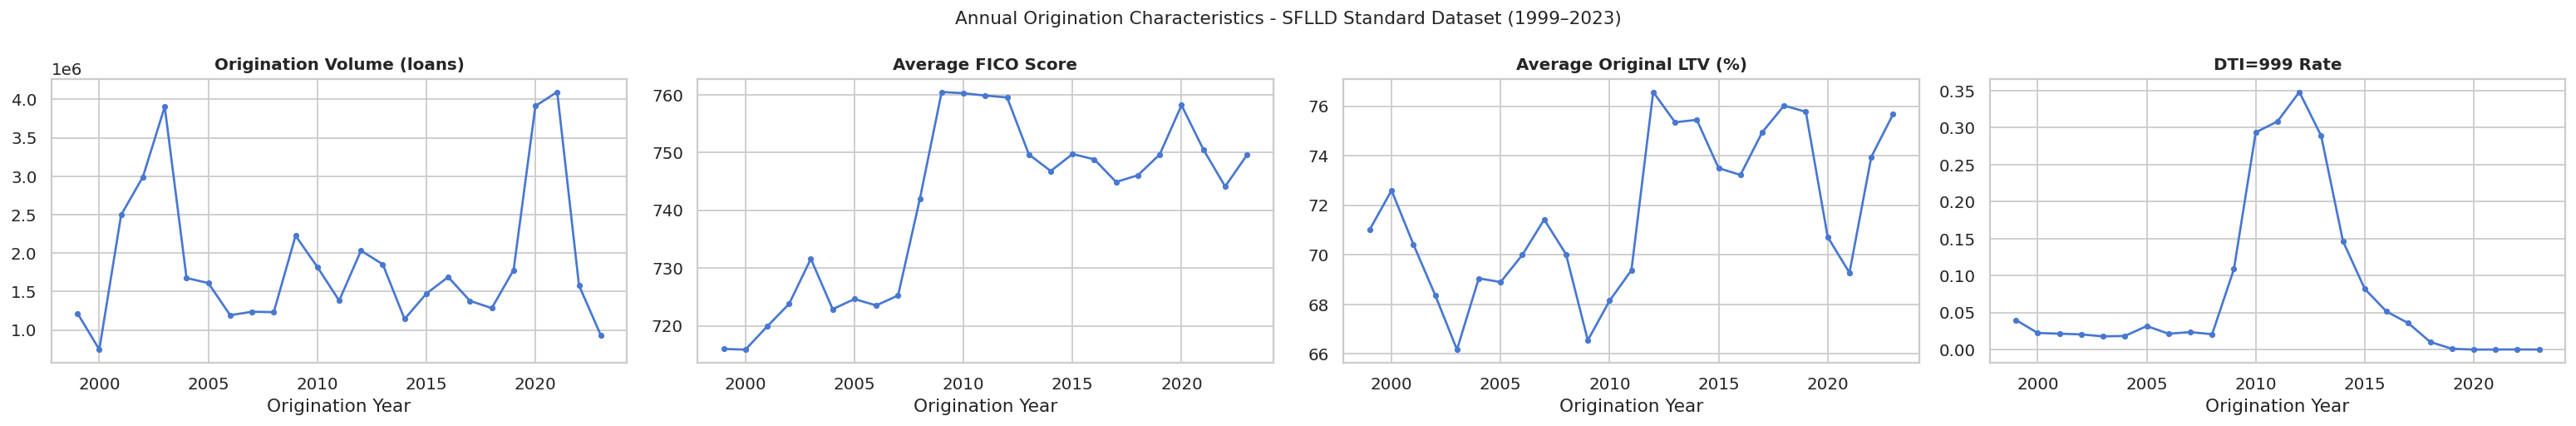

In [ ]:
vintage_orig = con.execute("""
SELECT
    vintage_year, vintage_quarter,
    COUNT(*) AS n_loans,
    ROUND(AVG(CASE WHEN credit_score != 9999 THEN credit_score END), 1) AS avg_fico,
    ROUND(AVG(CASE WHEN original_loan_to_value != 999 THEN original_loan_to_value END), 1) AS avg_orig_ltv,
    ROUND(AVG(CASE WHEN original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END), 1) AS avg_observed_dti,
    ROUND(AVG(CASE WHEN credit_score = 9999 THEN 1.0 ELSE 0.0 END), 4) AS pct_fico_9999,
    ROUND(AVG(CASE WHEN original_debt_to_income_ratio = 999 THEN 1.0 ELSE 0.0 END), 4) AS pct_dti_999,
    ROUND(AVG(CASE WHEN TRIM(relief_refinance_indicator) = 'Y' THEN 1.0 ELSE 0.0 END), 4) AS pct_relief_refi,
    ROUND(AVG(original_interest_rate), 2) AS avg_orig_rate
FROM sf_origination
WHERE vintage_year <= 2023
GROUP BY 1, 2 ORDER BY 1, 2
""").df()

display(vintage_orig.head(20))

annual = (vintage_orig.groupby("vintage_year", as_index=False)
          .agg(n_loans=("n_loans","sum"), avg_fico=("avg_fico","mean"),
               avg_orig_ltv=("avg_orig_ltv","mean"), pct_dti_999=("pct_dti_999","mean")))

fig, axes = plt.subplots(1, 4, figsize=(24, 4))
for ax, col, title in zip(axes,
    ["n_loans", "avg_fico", "avg_orig_ltv", "pct_dti_999"],
    ["Origination Volume (loans)", "Average FICO Score", "Average Original LTV (%)", "DTI=999 Rate"]):
    ax.plot(annual["vintage_year"], annual[col], marker="o", markersize=3)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Origination Year")
plt.suptitle("Annual Origination Characteristics - SFLLD Standard Dataset (1999-2023)", fontsize=12)
plt.tight_layout()
plt.show()

### 4.1b · DTI = 999 by Vintage

This table breaks the §2.6 DTI=999 mechanisms (censored >65%, unknown, Relief-Refinance masking) down by origination vintage, confirming the prevalence is regime-dependent rather than random - see §2.6 for the full interpretation and downstream-handling rationale (sentinel → NULL plus missingness indicator, no median imputation).

In [ ]:
print("=== Annual DTI = 999 interpretation panel ===")

dti_vintage_interpretation = con.execute("""
SELECT
    vintage_year,
    COUNT(*) AS n_loans,
    ROUND(100.0 * AVG(CASE WHEN original_debt_to_income_ratio = 999 THEN 1.0 ELSE 0.0 END), 2) AS pct_dti_999,
    ROUND(100.0 * AVG(CASE WHEN TRIM(relief_refinance_indicator) = 'Y' THEN 1.0 ELSE 0.0 END), 2) AS pct_relief_refi,
    ROUND(
        100.0 * AVG(
            CASE
                WHEN TRIM(relief_refinance_indicator) = 'Y'
                 AND original_debt_to_income_ratio = 999
                THEN 1.0 ELSE 0.0
            END
        ),
        2
    ) AS pct_relief_refi_and_dti_999,
    ROUND(
        100.0 * AVG(
            CASE
                WHEN TRIM(relief_refinance_indicator) IS DISTINCT FROM 'Y'
                 AND original_debt_to_income_ratio = 999
                THEN 1.0 ELSE 0.0
            END
        ),
        2
    ) AS pct_non_relief_and_dti_999
FROM sf_origination
GROUP BY 1
ORDER BY 1
""").df()

display(dti_vintage_interpretation)

summary = con.execute("""
WITH annual AS (
    SELECT
        vintage_year,
        AVG(CASE WHEN original_debt_to_income_ratio = 999 THEN 1.0 ELSE 0.0 END) AS dti_999_rate,
        AVG(CASE WHEN TRIM(relief_refinance_indicator) = 'Y' THEN 1.0 ELSE 0.0 END) AS relief_refi_rate
    FROM sf_origination
    GROUP BY 1
)
SELECT
    ROUND(100.0 * MIN(dti_999_rate), 2) AS min_pct_dti_999,
    ROUND(100.0 * MAX(dti_999_rate), 2) AS max_pct_dti_999,
    ROUND(100.0 * MIN(relief_refi_rate), 2) AS min_pct_relief_refi,
    ROUND(100.0 * MAX(relief_refi_rate), 2) AS max_pct_relief_refi
FROM annual
""").df()

print("\n=== Annual range summary ===")
display(summary)

=== Annual DTI = 999 interpretation panel ===


,vintage_year,n_loans,pct_dti_999,pct_relief_refi,pct_relief_refi_and_dti_999,pct_non_relief_and_dti_999
0,1999,1217693,4.24,0.00,0.00,4.24
1,2000,746368,2.16,0.00,0.00,2.16
2,2001,2497047,2.25,0.00,0.00,2.25
3,2002,2992676,2.11,0.00,0.00,2.11
4,2003,3904406,1.78,0.00,0.00,1.78
5,2004,1677203,1.85,0.00,0.00,1.85
6,2005,1611455,3.20,0.00,0.00,3.20
7,2006,1193544,2.15,0.00,0.00,2.15
8,2007,1238192,2.34,0.00,0.00,2.34
9,2008,1233146,2.19,0.00,0.00,2.19



=== Annual range summary ===


,min_pct_dti_999,max_pct_dti_999,min_pct_relief_refi,max_pct_relief_refi
0,0.0,34.48,0.0,34.47


---
## Section 5 · Thesis-Specific EDA

**Model scope:** As defined in §0.4.

**Naming note:** Legacy `Subprime` regime labels / `test_subprime` denote the
thesis's **Crisis (2007-2012)** window, not the FICO tier `Subprime (<640)`.

**Two-level failure taxonomy:** This notebook motivates, rather than establishes, the
thesis's two-level decomposition:

- **Level 1 - Intrinsic vulnerability:** Present at the calibration anchor before
  calibration-to-test movement. At the roughly 1% forward positive rate documented
  in §5.6, the pooled SCP threshold is effectively a majority-class score quantile.
  Downstream coverage analysis establishes the resulting conditional failure; the
  isotonic map affects its severity rather than the basic pooled-threshold mechanism.

- **Level 2 - Distributional modulation:** Later windows differ from calibration in
  class composition, covariates, policy context and portfolio mix. The EDA provides
  descriptive evidence consistent with the four *a priori* regime labels - tail shift,
  stable drift, structural shift and composition shift - without identifying those
  mechanisms causally.

### 5.1 · Monthly Positive-Class Rate Time Series  *(Figure 1)*

Portfolio-wide share of active loans meeting the **thesis positive-class condition**
for every reporting month from 1999 onward. The chart covers the full Release 46 dataset;
a vertical line marks **December 2023**, the end of the thesis analysis window (all six
panel splits close at or before this date).

The positive class is defined as:

- **strict 60+ delinquency** (`DQ60_ONLY`), or
- **REO Acquisition** (`RA` / legacy `R`)

For clarity, this figure is labelled **"60+ DPD or REO Acquisition"** throughout.
The strict `DQ60_ONLY` series is shown as a dashed overlay; the gap between the two
lines represents the marginal contribution of REO-acquisition codes.

The figure marks the declared 1999-2004 training/validation window and the
2005-2006 calibration window; NB04 fits on 1999-2003 and uses 2004 for early
stopping. Four test regimes are defined, while the figure highlights the three
event-labelled stress periods.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

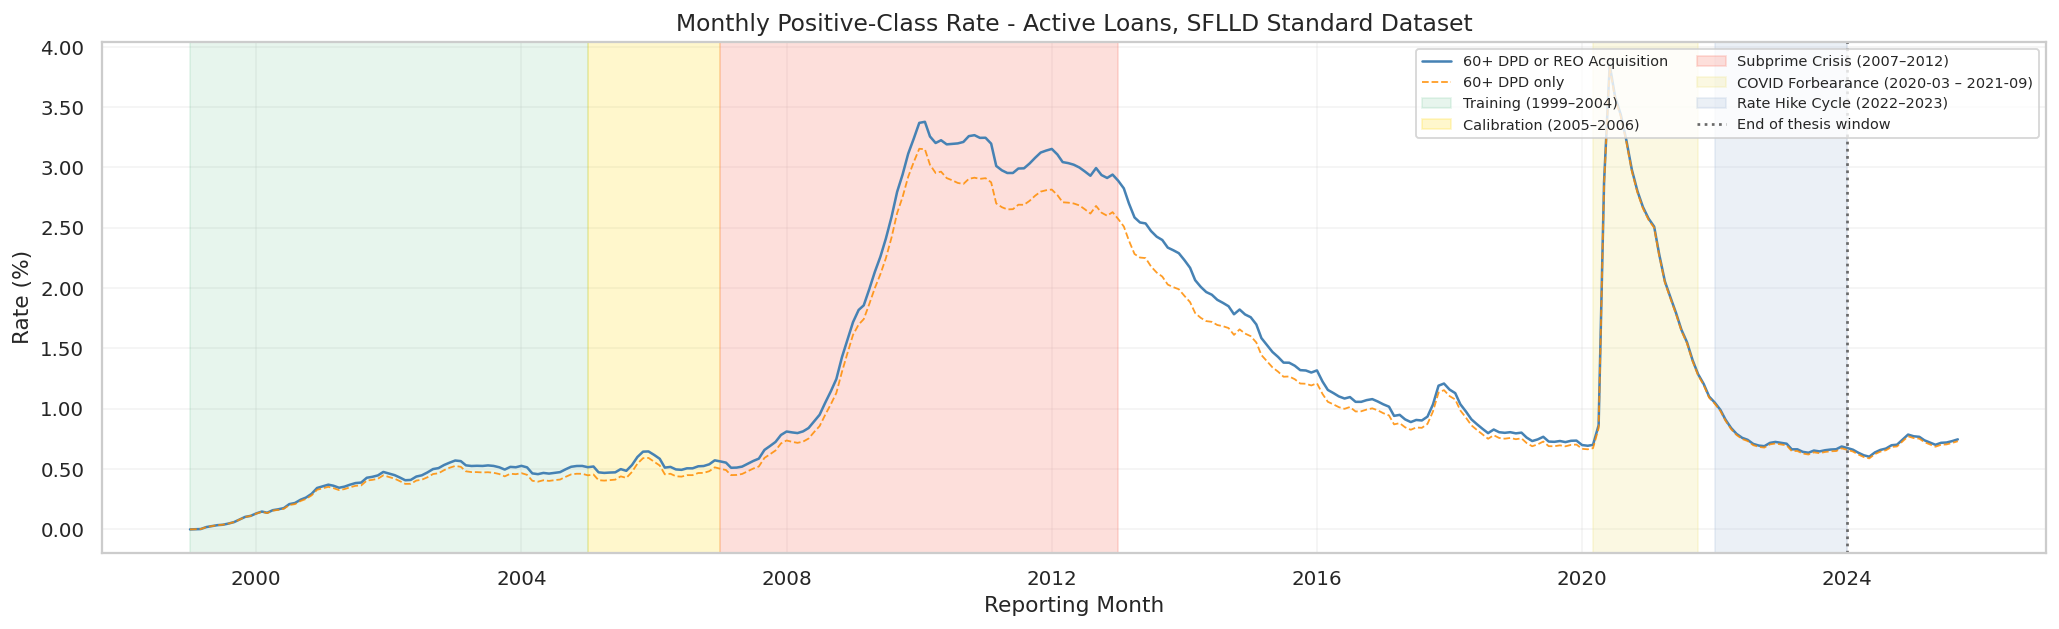

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,avg_pos_class_rate,avg_dq60_only_rate
0,0.013697,0.012715


In [ ]:
dq_ts = con.execute(f"""
SELECT
    monthly_reporting_period,
    COUNT(*) AS n_active_obs,
    ROUND(AVG(CASE WHEN {POS_CLASS} THEN 1.0 ELSE 0.0 END), 6) AS pos_class_rate,
    ROUND(AVG(CASE WHEN {DQ60_ONLY} THEN 1.0 ELSE 0.0 END), 6) AS dq60_only_rate
FROM sf_performance_by_period
WHERE zero_balance_code IS NULL
GROUP BY 1
ORDER BY 1
""").df()

dq_ts["monthly_reporting_period"] = pd.to_datetime(dq_ts["monthly_reporting_period"])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    dq_ts["monthly_reporting_period"],
    dq_ts["pos_class_rate"] * 100,
    lw=1.4, color="steelblue", label="60+ DPD or REO Acquisition"
)
ax.plot(
    dq_ts["monthly_reporting_period"],
    dq_ts["dq60_only_rate"] * 100,
    lw=1.0, ls="--", color="darkorange", alpha=0.85, label="60+ DPD only"
)

# Training and calibration windows
ax.axvspan(pd.Timestamp("1999-01-01"), pd.Timestamp("2004-12-31"),
           alpha=0.12, color="mediumseagreen", label="Training (1999-2004)")
ax.axvspan(pd.Timestamp("2005-01-01"), pd.Timestamp("2006-12-31"),
           alpha=0.20, color="gold", label="Calibration (2005-2006)")

# Test regimes
test_regimes = [
    ("2007-01-01", "2012-12-31", "salmon",         "Subprime Crisis (2007-2012)"),
    ("2020-03-01", "2021-09-30", "khaki",           "COVID Forbearance (2020-03 - 2021-09)"),
    ("2022-01-01", "2023-12-31", "lightsteelblue",  "Rate Hike Cycle (2022-2023)"),
]
for start, end, colour, lbl in test_regimes:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.25, color=colour, label=lbl)

# End of thesis analysis window
ax.axvline(pd.Timestamp("2023-12-31"), color="dimgray", lw=1.5, ls=":", label="End of thesis window")

ax.set_title("Monthly Positive-Class Rate - Active Loans, SFLLD Standard Dataset", fontsize=13)
ax.set_xlabel("Reporting Month")
ax.set_ylabel("Rate (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(loc="upper right", ncol=2, fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

diff_summary = con.execute(f"""
SELECT
    ROUND(AVG(CASE WHEN {POS_CLASS} THEN 1.0 ELSE 0.0 END), 6) AS avg_pos_class_rate,
    ROUND(AVG(CASE WHEN {DQ60_ONLY} THEN 1.0 ELSE 0.0 END), 6) AS avg_dq60_only_rate
FROM sf_performance_by_period
WHERE zero_balance_code IS NULL
""").df()
display(diff_summary)

### 5.2 · Vintage Delinquency Curves

Realized 60+ DPD or REO Acquisition rate by loan age for selected origination vintages. This is an age-specific stock measure over observed history: at each loan age, it shows the share of surviving active loan-months currently positive.

The chart is descriptive, but reflects the same event-history structure underlying the thesis design (§0.4): risk varies with vintage, time since origination, and macro-regime.

**Loan-age reset interpretation:** As established in §3.1, `loan_age` resets at modification (not at payment deferral). A modified 2009 vintage loan with `loan_age = 24` may actually be much older in original-loan time, so high-modification vintages can show compressed visible loan-age curves that understate true seasoning.

The chart highlights 2006-2008 originations as descriptive mortgage-cycle
heterogeneity motivating the out-of-time regime design.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

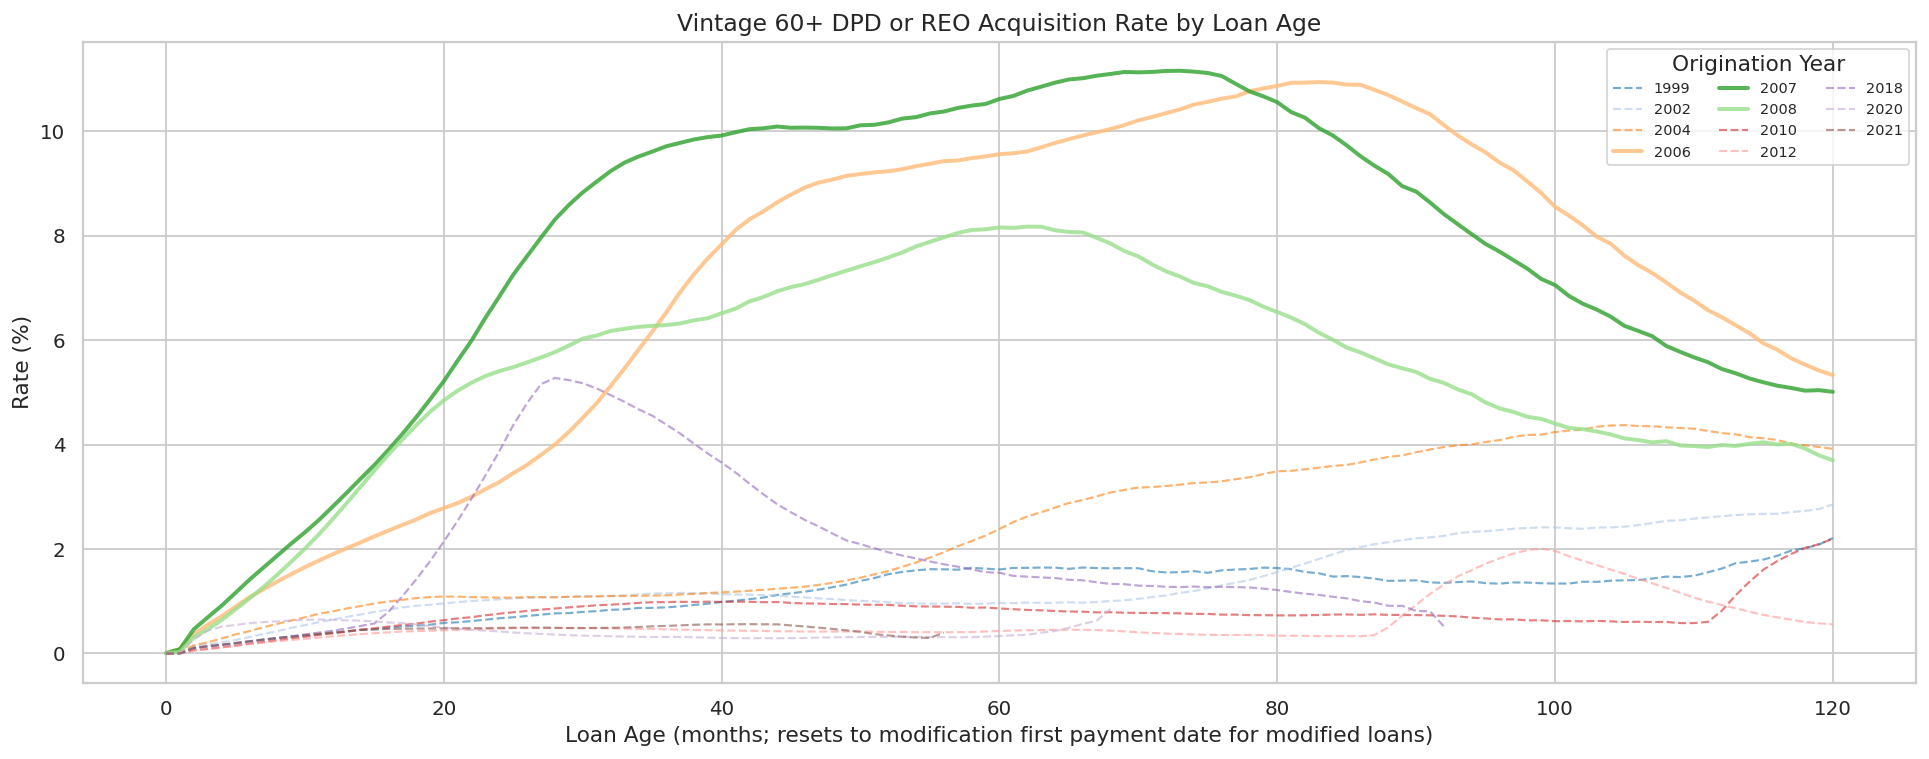

In [ ]:
HIGHLIGHT_VINTAGES = [1999, 2002, 2004, 2006, 2007, 2008, 2010, 2012, 2018, 2020, 2021]

con.execute("PRAGMA disable_optimizer;")  # Disable optimizer to bypass 'Perfect hash aggregate' error
try:
    dq_curves = con.execute(f"""
WITH joined AS (
    SELECT o.vintage_year, p.loan_age,
           CASE WHEN {POS_CLASS_P} THEN 1.0 ELSE 0.0 END AS is_positive
    FROM sf_performance p
    INNER JOIN sf_origination o USING (loan_sequence_number)
    WHERE p.zero_balance_code IS NULL
      AND p.loan_age BETWEEN 0 AND 120
      AND o.vintage_year IN ({','.join(map(str, HIGHLIGHT_VINTAGES))})
)
SELECT vintage_year, loan_age, COUNT(*) AS n_obs,
       ROUND(AVG(is_positive), 6) AS dq_or_reo_rate
FROM joined
GROUP BY 1, 2 ORDER BY 1, 2
""").df()
finally:
    con.execute("PRAGMA enable_optimizer;")  # Always re-enable, even if query fails

fig, ax = plt.subplots(figsize=(15, 6))
palette = plt.cm.tab20.colors
for i, yr in enumerate(HIGHLIGHT_VINTAGES):
    sub = dq_curves[dq_curves["vintage_year"] == yr]
    if sub.empty: continue
    lw = 2.2 if yr in (2006, 2007, 2008) else 1.2
    ls = "-"  if yr in (2006, 2007, 2008) else "--"
    ax.plot(sub["loan_age"], sub["dq_or_reo_rate"] * 100,
            lw=lw, ls=ls, alpha=0.8 if lw > 1.5 else 0.6,
            color=palette[i % len(palette)], label=str(yr))

ax.set_title("Vintage 60+ DPD or REO Acquisition Rate by Loan Age", fontsize=13)
ax.set_xlabel("Loan Age (months; resets to modification first payment date for modified loans)")
ax.set_ylabel("Rate (%)")
ax.legend(title="Origination Year", fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

### 5.3 · COVID Forbearance Field Analysis

**`borrower_assistance_status_code` semantics:**
- `F` = Forbearance
- `R` = Repayment
- `T` = Trial Period

A binary flag constructed from `IS NOT NULL` captures **all three** and should therefore be
labelled **"in workout plan"** or **"assisted"**, not simply "forbearance."

This field is only populated from **January 2014 onward**. It is therefore structurally
missing in the 1999-2003 training window and should be interpreted as a later-regime
descriptive variable rather than a time-stable feature available across the full sample.

**Why this matters for thesis interpretation:**

COVID-era distress measures are not purely borrower-fundamental signals.
They are shaped by both:

- borrower payment stress, and
- policy / servicing interventions such as forbearance, repayment plans, trial modifications, and foreclosure suppression.

So when assisted loans show a high rate of **60+ DPD or REO Acquisition**, that does **not**
mean the field is a simple causal risk driver. It is partly a marker of entry into an intervention regime.

This is especially important because the downstream thesis problem is a **transition-risk** problem.
The model is not trying to explain all mortgage distress in the abstract. It is trying to predict
whether active current / 30-DPD loans transition into materially worse states under changing regimes.

Accordingly, this section should be read as a **regime-interpretation diagnostic**, not as evidence
that workout-plan status is a clean, time-invariant structural feature.

**NB03 feature exclusion:** `in_workout_plan_flag` is hard-excluded from the NB03 active feature set (see §3.1 consolidated table) and retained as a diagnostic metadata column.

In [ ]:
print("=== Workout-plan code distribution (March 2020 - September 2021) ===")

workout_freq = con.execute("""
SELECT
    borrower_assistance_status_code AS code,
    CASE
        WHEN borrower_assistance_status_code = 'F' THEN 'F - Forbearance'
        WHEN borrower_assistance_status_code = 'R' THEN 'R - Repayment'
        WHEN borrower_assistance_status_code = 'T' THEN 'T - Trial Period'
        WHEN borrower_assistance_status_code IS NULL THEN 'NULL - No active workout plan'
        ELSE 'Other'
    END AS description,
    payment_deferral_flag,
    COUNT(*) AS n_rows,
    COUNT(DISTINCT loan_sequence_number) AS n_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 4) AS pct_rows
FROM sf_performance_by_period
WHERE monthly_reporting_period BETWEEN '2020-03-01' AND '2021-09-30'
GROUP BY 1, 2, 3
ORDER BY n_rows DESC
""").df()
display(workout_freq)

print("\n=== 60+ DPD or REO rate: in-workout-plan vs. not (COVID window) ===")
dq_vs_workout = con.execute(f"""
SELECT
    CASE
        WHEN borrower_assistance_status_code IS NOT NULL THEN 'in_workout_plan'
        ELSE 'no_workout_plan'
    END AS workout_status,
    COUNT(*) AS n_obs,
    ROUND(AVG(CASE WHEN {POS_CLASS} THEN 1.0 ELSE 0.0 END), 6) AS rate_pos_class
FROM sf_performance_by_period
WHERE monthly_reporting_period BETWEEN '2020-03-01' AND '2021-09-30'
  AND zero_balance_code IS NULL
GROUP BY 1
""").df()
display(dq_vs_workout)

print("Interpretation note:")
print("  'in_workout_plan' is a regime/status marker, not a pure structural borrower feature.")
print("  It combines forbearance, repayment plans, and trial-period activity.")
print("  Elevated positive-class rates in this group should be read jointly with the COVID policy regime.")

=== Workout-plan code distribution (March 2020 – September 2021) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,code,description,payment_deferral_flag,n_rows,n_loans,pct_rows
0,None,NULL – No active workout plan,None,210111319,17136824,96.4180
1,F,F – Forbearance,None,4993525,720499,2.2915
2,None,NULL – No active workout plan,P,2039706,277120,0.9360
3,F,F – Forbearance,P,278505,63748,0.1278
4,None,NULL – No active workout plan,Y,165861,163504,0.0761
5,T,T – Trial Period,None,143471,48225,0.0658
6,F,F – Forbearance,Y,130362,129251,0.0598
7,R,R – Repayment,None,45104,13208,0.0207
8,T,T – Trial Period,P,6136,2205,0.0028
9,R,R – Repayment,P,2820,924,0.0013



=== 60+ DPD or REO rate: in-workout-plan vs. not (COVID window) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,workout_status,n_obs,rate_pos_class
0,in_workout_plan,5600030,0.699339
1,no_workout_plan,207305845,0.005121


Interpretation note:
  'in_workout_plan' is a regime/status marker, not a pure structural borrower feature.
  It combines forbearance, repayment plans, and trial-period activity.
  Elevated positive-class rates in this group should be read jointly with the COVID policy regime.


### 5.4 · Calibration-Window Cell Support - Contemporaneous Distress

This is a descriptive EDA check of FICO×LTV cell size and current 60+ DPD/REO
counts in 2005-2006. It is not the forward `y=1` count or the actual Mondrian
calibration sample.

Downstream Mondrian thresholds use all `cp_cal` rows within each cell; NB03 and
NB05b perform the relevant calibration-cell-size checks. The `MONDRIAN_MIN_*`
flags here are exploratory only and do not define pipeline eligibility.

=== Calibration-window positive-class counts by FICO × LTV cell (2005-2006) ===
Stock of currently-distressed active loans per cell during the calibration window.



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,fico_tier,ltv_bucket,n_loan_month_obs,n_pos_class_obs,pos_rate_pct
0,Near-Prime (640-719),High LTV (>95%),586065,13036.0,2.2243
1,Near-Prime (640-719),Low LTV (<=80%),48165468,279776.0,0.5809
2,Near-Prime (640-719),Moderate LTV (81-95%),9815956,176214.0,1.7952
3,Near-Prime (640-719),Unknown LTV (sentinel),4418,46.0,1.0412
4,Prime (>=720),High LTV (>95%),484720,4366.0,0.9007
5,Prime (>=720),Low LTV (<=80%),102230295,89405.0,0.0875
6,Prime (>=720),Moderate LTV (81-95%),8841413,37601.0,0.4253
7,Prime (>=720),Unknown LTV (sentinel),14170,10.0,0.0706
8,Subprime (<640),High LTV (>95%),112803,4584.0,4.0637
9,Subprime (<640),Low LTV (<=80%),9223051,214989.0,2.3310


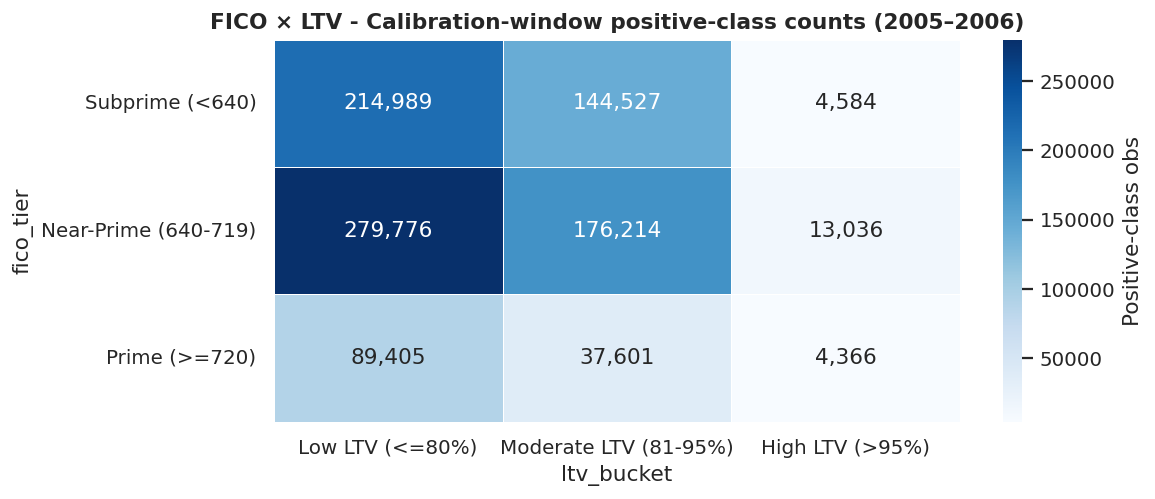


✓  All FICO×LTV cells exceed 500 active observations in the calibration window.

✓  All FICO×LTV cells have ≥ 10 positive-class observations in the calibration window.


In [ ]:
print("=== Calibration-window positive-class counts by FICO × LTV cell (2005-2006) ===")
print("Stock of currently-distressed active loans per cell during the calibration window.\n")

FICO_TIER_CASE = """
    CASE WHEN o.credit_score IS NULL OR o.credit_score = 9999 THEN 'Unknown FICO'
         WHEN o.credit_score < 640                             THEN 'Subprime (<640)'
         WHEN o.credit_score < 720                             THEN 'Near-Prime (640-719)'
         ELSE                                                       'Prime (>=720)'
    END
"""
LTV_BUCKET_CASE = """
    CASE WHEN o.original_loan_to_value IS NULL OR o.original_loan_to_value = 999 THEN 'Unknown LTV'
         WHEN o.original_loan_to_value <= 80                                      THEN 'Low LTV (<=80%)'
         WHEN o.original_loan_to_value <= 95                                      THEN 'Moderate LTV (81-95%)'
         ELSE                                                                          'High LTV (>95%)'
    END
"""

calib_pos = con.execute(f"""
SELECT
    {FICO_TIER_CASE} AS fico_tier,
    CASE WHEN o.original_loan_to_value IS NULL OR o.original_loan_to_value = 999 THEN 'Unknown LTV (sentinel)'
         WHEN o.original_loan_to_value <= 80                                      THEN 'Low LTV (<=80%)'
         WHEN o.original_loan_to_value <= 95                                      THEN 'Moderate LTV (81-95%)'
         ELSE                                                                          'High LTV (>95%)'
    END AS ltv_bucket,
    COUNT(*)                                                              AS n_loan_month_obs,
    SUM(CASE WHEN {POS_CLASS_P} THEN 1 ELSE 0 END)                       AS n_pos_class_obs,
    ROUND(100.0 * AVG(CASE WHEN {POS_CLASS_P} THEN 1.0 ELSE 0.0 END), 4) AS pos_rate_pct
FROM sf_performance_by_period p
JOIN sf_origination o USING (loan_sequence_number)
WHERE p.monthly_reporting_period BETWEEN '2005-01-01' AND '2006-12-31'
  AND p.zero_balance_code IS NULL
GROUP BY 1, 2
ORDER BY 1, 2
""").df()
display(calib_pos)

FICO_ORDER = ["Subprime (<640)", "Near-Prime (640-719)", "Prime (>=720)"]
LTV_ORDER  = ["Low LTV (<=80%)", "Moderate LTV (81-95%)", "High LTV (>95%)"]
heat_data = (
    calib_pos[calib_pos["fico_tier"].isin(FICO_ORDER) &
              calib_pos["ltv_bucket"].isin(LTV_ORDER)]
    .pivot(index="fico_tier", columns="ltv_bucket", values="n_pos_class_obs")
    .reindex(index=FICO_ORDER, columns=LTV_ORDER)
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heat_data, annot=True, fmt=",.0f", cmap="Blues",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Positive-class obs"})
ax.set_title("FICO × LTV - Calibration-window positive-class counts (2005-2006)",
             fontweight="bold")
plt.tight_layout()
plt.show()

# Loan-month screen on the active calibration stock, reusing the MONDRIAN_MIN_CELL value (500)
MONDRIAN_MIN_CELL = 500
sparse = calib_pos[
    calib_pos["fico_tier"].isin(FICO_ORDER) &
    calib_pos["ltv_bucket"].isin(LTV_ORDER) &
    (calib_pos["n_loan_month_obs"] < MONDRIAN_MIN_CELL)
]
if len(sparse):
    print(f"\n⚠  Cells with fewer than {MONDRIAN_MIN_CELL} total loan-month observations (loan-month screen):")
    print(sparse[["fico_tier","ltv_bucket","n_loan_month_obs","n_pos_class_obs","pos_rate_pct"]].to_string(index=False))
else:
    print(f"\n✓  All FICO×LTV cells exceed {MONDRIAN_MIN_CELL} active observations in the calibration window.")

# Secondary flag: positive-class count - the binding constraint for coverage assessment
MONDRIAN_MIN_POS = 10
sparse_pos = calib_pos[
    calib_pos["fico_tier"].isin(FICO_ORDER) &
    calib_pos["ltv_bucket"].isin(LTV_ORDER) &
    (calib_pos["n_pos_class_obs"] < MONDRIAN_MIN_POS)
]
if len(sparse_pos):
    print(f"\n⚠  Cells with fewer than {MONDRIAN_MIN_POS} positive-class observations:")
    print(sparse_pos[["fico_tier","ltv_bucket","n_loan_month_obs","n_pos_class_obs","pos_rate_pct"]].to_string(index=False))
    print("    Fewer positive-class observations impair stable positive-class coverage assessment.")
else:
    print(f"\n✓  All FICO×LTV cells have ≥ {MONDRIAN_MIN_POS} positive-class observations in the calibration window.")

### 5.5 · Calibration Window Verification

This section checks raw 2005-2006 stock size across FICO×LTV cells; actual
panel/`cp_cal` Mondrian support, including `Sentinel`, is checked in NB03/NB05b.

**Forward-label boundary caveat:** Because labels use `(t, t+12]`, all calibration
rows from January 2006 onward have horizons reaching into 2007; NB03 quantifies
this as 51.8% of calibration rows. The aggregate positive-rate effect is small and
negative (−0.0183 pp against the clean-half counterfactual), and it does not
identify the corresponding effect on the conformal threshold.

In [ ]:
print("=== Calibration window total size (2005-2006, active loans) ===")
calib_total = con.execute("""
SELECT
    COUNT(*) AS n_loan_month_obs,
    COUNT(DISTINCT loan_sequence_number) AS n_distinct_loans,
    MIN(monthly_reporting_period) AS first_month,
    MAX(monthly_reporting_period) AS last_month
FROM sf_performance_by_period
WHERE monthly_reporting_period BETWEEN '2005-01-01' AND '2006-12-31'
  AND zero_balance_code IS NULL
""").df()
display(calib_total)

print("\n=== Calibration counts by FICO tier × LTV bucket ===")
calib_subgroups = con.execute(f"""
SELECT
    {FICO_TIER_CASE} AS fico_tier,
    CASE WHEN o.original_loan_to_value IS NULL OR o.original_loan_to_value = 999 THEN 'Unknown LTV'
         WHEN o.original_loan_to_value <= 80                                      THEN 'Low LTV (<=80%)'
         WHEN o.original_loan_to_value <= 95                                      THEN 'Moderate LTV (81-95%)'
         ELSE                                                                          'High LTV (>95%)'
    END AS ltv_bucket,
    COUNT(*) AS n_loan_month_obs,
    COUNT(DISTINCT p.loan_sequence_number) AS n_distinct_loans
FROM sf_performance_by_period p
JOIN sf_origination o USING (loan_sequence_number)
WHERE p.monthly_reporting_period BETWEEN '2005-01-01' AND '2006-12-31'
  AND p.zero_balance_code IS NULL
GROUP BY 1, 2 ORDER BY 1, 2
""").df()
display(calib_subgroups)

=== Calibration window total size (2005-2006, active loans) ===


,n_loan_month_obs,n_distinct_loans,first_month,last_month
0,182706108,9845526,2005-01-01,2006-12-01



=== Calibration counts by FICO tier × LTV bucket ===


,fico_tier,ltv_bucket,n_loan_month_obs,n_distinct_loans
0,Near-Prime (640-719),High LTV (>95%),586065,39129
1,Near-Prime (640-719),Low LTV (<=80%),48165468,2675410
2,Near-Prime (640-719),Moderate LTV (81-95%),9815956,551222
3,Near-Prime (640-719),Unknown LTV,4418,228
4,Prime (>=720),High LTV (>95%),484720,29632
5,Prime (>=720),Low LTV (<=80%),102230295,5341687
6,Prime (>=720),Moderate LTV (81-95%),8841413,481746
7,Prime (>=720),Unknown LTV,14170,739
8,Subprime (<640),High LTV (>95%),112803,9140
9,Subprime (<640),Low LTV (<=80%),9223051,535332


### 5.6 · Forward-Looking Class Imbalance - Transition-Risk Positive Rate

The downstream thesis target is a **transition-risk** measure. A base observation is eligible only when the loan is active and currently at current or 30-DPD status. It is labelled positive if the loan enters 60+ DPD or REO Acquisition within the next 12 months.

This section reports the forward-looking positive rate for each panel split. The
base population and target-event definition match NB03. A deterministic 10%
loan sample is used for tractability, so the estimates should approximate rather
than exactly reproduce the full-panel manifest rates.

The calibration-window rate is the class-imbalance reference for Level 1; the
actual Level-1 coverage failure is established downstream on the calibration
partition.

Release 46 provides sufficient history to close every retained 12-month label
window. The fixed 12-month target nevertheless does not measure credit responses
occurring beyond that horizon, so no causal interpretation of the low rate-hike
positive rate is made here.

In [ ]:
POS_CLASS_F = pos_class_for("f")

# Split windows match NB03 exactly. test_normal ends 2019-09-30 (not 2019-12-31) to reduce
# COVID forward-window contamination: Oct-Dec 2019 observations have forward label windows
# that extend into early COVID (Oct-Dec 2020). NB04 enforces this via manifest contract assertion.
SPLIT_WINDOWS = {
    "Training (1999-2004)":    ("1999-01-01", "2004-12-31"),
    "Calibration (2005-2006)": ("2005-01-01", "2006-12-31"),
    "Subprime (2007-2012)":    ("2007-01-01", "2012-12-31"),
    "Normal (2013-Sep 2019)":  ("2013-01-01", "2019-09-30"),
    "COVID (2020-2021)":       ("2020-03-01", "2021-09-30"),
    "Rate Hike (2022-2023)":   ("2022-01-01", "2023-12-31"),
}

rows = []
for label, (start, end) in SPLIT_WINDOWS.items():
    print(f"  Computing {label}...", end=" ", flush=True)
    r = con.execute(f"""
    WITH base_obs AS (
        SELECT p.loan_sequence_number,
               p.monthly_reporting_period AS obs_date,
               p.monthly_reporting_period + INTERVAL '12' MONTH AS horizon_date
        FROM sf_performance_by_period p
        WHERE p.monthly_reporting_period BETWEEN '{start}' AND '{end}'
          AND p.zero_balance_code IS NULL
          AND p.loan_age >= 1
          AND p.current_loan_delinquency_status IN ('0', '00', '1')
          AND hash(p.loan_sequence_number) % 10 = 0
    ),
    forward_events AS (
        SELECT DISTINCT b.loan_sequence_number, b.obs_date
        FROM base_obs b
        JOIN sf_performance_by_period f
          ON  f.loan_sequence_number = b.loan_sequence_number
          AND f.monthly_reporting_period >  b.obs_date
          AND f.monthly_reporting_period <= b.horizon_date
        WHERE f.zero_balance_code IS NULL
          AND ({POS_CLASS_F})
    )
    SELECT
        COUNT(*) AS n_base_observations,
        SUM(CASE WHEN fe.loan_sequence_number IS NOT NULL THEN 1 ELSE 0 END) AS n_positive,
        SUM(CASE WHEN fe.loan_sequence_number IS NULL     THEN 1 ELSE 0 END) AS n_negative,
        ROUND(100.0 * AVG(CASE WHEN fe.loan_sequence_number IS NOT NULL THEN 1.0 ELSE 0.0 END), 4)
            AS positive_rate_pct
    FROM base_obs b
    LEFT JOIN forward_events fe
      ON  b.loan_sequence_number = fe.loan_sequence_number
      AND b.obs_date             = fe.obs_date
    """).df()
    pos_rate = float(r['positive_rate_pct'].iloc[0])
    rows.append({"Split window": label, **r.iloc[0].to_dict()})
    print(f"{pos_rate:.4f}%")

imbalance_df = pd.DataFrame(rows)
print("\n=== Forward-looking positive rate by split window (10% loan sample) ===")
display(imbalance_df)
print("\nNote: positive class = 60+ DPD or REO Acquisition in the 12 months after observation.")
calib_row = imbalance_df[imbalance_df["Split window"].str.contains("Calibration")]
calib_rate_pct = float(calib_row["positive_rate_pct"].iloc[0]) if len(calib_row) else float("nan")
print(f"      Calibration window forward-positive rate ({calib_rate_pct:.4f}%) is the Level 1 intrinsic-failure anchor.")

sub_row  = imbalance_df[imbalance_df["Split window"].str.contains("Subprime")]
sub_rate = float(sub_row["positive_rate_pct"].iloc[0]) if len(sub_row) else float("nan")
if np.isfinite(sub_rate) and np.isfinite(calib_rate_pct):
    rel = "above" if sub_rate > calib_rate_pct else ("below" if sub_rate < calib_rate_pct else "equal to")
    print(f"      Subprime window rate ({sub_rate:.4f}%) is {rel} the calibration window rate "
          f"({calib_rate_pct:.4f}%) - Level 2 distributional-shift context.")

  Computing Training (1999–2004)... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

1.1605%
  Computing Calibration (2005–2006)... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

1.1017%
  Computing Subprime (2007–2012)... 

...

1.6766%
  Computing Rate Hike (2022–2023)... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

1.0491%

=== Forward-looking positive rate by split window (10% loan sample) ===


,Split window,n_base_observations,n_positive,n_negative,positive_rate_pct
0,Training (1999–2004),24820899.0,288052.0,24532847.0,1.1605
1,Calibration (2005–2006),17914455.0,197357.0,17717098.0,1.1017
2,Subprime (2007–2012),63248179.0,1591419.0,61656760.0,2.5161
3,Normal (2013–Sep 2019),75296793.0,1141495.0,74155298.0,1.5160
4,COVID (2020–2021),20142870.0,337710.0,19805160.0,1.6766
5,Rate Hike (2022–2023),30642195.0,321459.0,30320736.0,1.0491



Note: positive class = 60+ DPD or REO Acquisition in the 12 months after observation.
      Calibration window forward-positive rate (1.1017%) is the Level 1 intrinsic-failure anchor.
      Subprime window rate (2.5161%) is above the calibration window rate (1.1017%) - Level 2 distributional-shift context.


### 5.7 · Geographic Coverage and MSA Availability

The panel retains `property_state` as metadata and uses derived `census_division`
as the geographic model/subgroup feature. This section checks MSA availability
and the geographic distribution of the source portfolio.

MSA is not used downstream; Census division provides the chosen coarser
geographic representation. NB03 maps the 50 states and DC to the official nine
Census divisions and pragmatically assigns territories to a nearby division,
while NB02 keeps territories separate for this diagnostic.

In [ ]:
print("=== MSA missingness ===")
msa_miss = con.execute("""
SELECT
    SUM(CASE WHEN msa_or_metropolitan_division IS NULL THEN 1 ELSE 0 END) AS n_missing_msa,
    COUNT(*) AS n_total,
    ROUND(100.0 * AVG(CASE WHEN msa_or_metropolitan_division IS NULL THEN 1.0 ELSE 0.0 END), 2) AS pct_missing_msa
FROM sf_origination
""").df()
display(msa_miss)

pct_miss = float(msa_miss["pct_missing_msa"].iloc[0])
if pct_miss > 20:
    print(f"⚠  {pct_miss:.1f}% of loans lack MSA codes → Census division for CP subgroups.")
else:
    print(f"✓  MSA available for {100-pct_miss:.1f}% of loans.")

print("\n=== Loan counts by U.S. Census Division ===")
print("Note: PR, VI, GU, AS, MP are U.S. territories and do not belong to any Census Bureau")
print("division. They are grouped separately to avoid distorting divisional proportions.")
census_counts = con.execute("""
SELECT
    CASE
        WHEN property_state IN ('CT','ME','MA','NH','RI','VT')              THEN '1-New England'
        WHEN property_state IN ('NJ','NY','PA')                             THEN '2-Middle Atlantic'
        WHEN property_state IN ('IL','IN','MI','OH','WI')                   THEN '3-E North Central'
        WHEN property_state IN ('IA','KS','MN','MO','NE','ND','SD')         THEN '4-W North Central'
        WHEN property_state IN ('DE','FL','GA','MD','NC','SC','VA','DC','WV') THEN '5-South Atlantic'
        WHEN property_state IN ('AL','KY','MS','TN')                        THEN '6-E South Central'
        WHEN property_state IN ('AR','LA','OK','TX')                        THEN '7-W South Central'
        WHEN property_state IN ('AZ','CO','ID','MT','NM','NV','UT','WY')    THEN '8-Mountain'
        WHEN property_state IN ('AK','CA','HI','OR','WA')                   THEN '9-Pacific'
        WHEN property_state IN ('PR','VI','GU','AS','MP')                   THEN '0-Territories'
        ELSE 'Unknown'
    END AS census_division,
    COUNT(*) AS n_loans
FROM sf_origination
GROUP BY 1 ORDER BY 1
""").df()
display(census_counts)

=== MSA missingness ===


,n_missing_msa,n_total,pct_missing_msa
0,11379122.0,48597637,23.41


⚠  23.4% of loans lack MSA codes → Census division for CP subgroups.

=== Loan counts by U.S. Census Division ===
Note: PR, VI, GU, AS, MP are U.S. territories and do not belong to any Census Bureau
division. They are grouped separately to avoid distorting divisional proportions.


,census_division,n_loans
0,0-Territories,74548
1,1-New England,2507124
2,2-Middle Atlantic,4651277
3,3-E North Central,8716965
4,4-W North Central,3862115
5,5-South Atlantic,9543080
6,6-E South Central,2177719
7,7-W South Central,3938794
8,8-Mountain,4685075
9,9-Pacific,8440939


### 5.8 · Subgroup Delinquency Rates by Reporting-Period Regime

This section asks whether the predefined FICO and LTV subgroup segments behave differently
across the six panel split regimes. Both dimensions are shown: FICO tier × regime and
LTV bucket × regime.

The classification here is by **reporting period** (`monthly_reporting_period`), not by
origination vintage. Each cell shows the contemporaneous positive-class rate - the share of
active loan-months in that period currently at 60+ DPD or REO Acquisition. This is a stock
measure, not a forward-looking transition rate (that is in §5.6).

**Regime gap periods:** The six regime windows do not cover all months. Two intentional
gaps exist as contamination buffers:
- **Oct 2019 - Feb 2020** (5 months): observations here have forward label windows
  overlapping early COVID; excluded from `test_normal` (ends 2019-09-30) and
  `test_covid` (starts 2020-03-01).
- **Oct 2021 - Dec 2021** (3 months): transition buffer between `test_covid`
  (ends 2021-09-30) and `test_rate_hike` (starts 2022-01-01).

Loan-months in these gap periods are in the SFLLD but are not assigned to any
panel split. The REGIME_CASE below maps them to NULL and they are excluded from the
displayed tables. They are also excluded from the NB03 panel by the split-window
boundary definitions.

If risk levels within a subgroup vary strongly across regimes, this supports the thesis
motivation that subgroup-level conformal coverage may deteriorate when the evaluation period
is no longer exchangeable with the calibration window - the empirical grounding for the
Level 2 distributional failure layer.

In [ ]:
REGIME_CASE = """
    CASE
        WHEN monthly_reporting_period BETWEEN '1999-01-01' AND '2004-12-31' THEN '1. Training (1999-2004)'
        WHEN monthly_reporting_period BETWEEN '2005-01-01' AND '2006-12-31' THEN '2. Calibration (2005-2006)'
        WHEN monthly_reporting_period BETWEEN '2007-01-01' AND '2012-12-31' THEN '3. Subprime (2007-2012)'
        WHEN monthly_reporting_period BETWEEN '2013-01-01' AND '2019-09-30' THEN '4. Normal (2013-Sep 2019)'
        WHEN monthly_reporting_period BETWEEN '2020-03-01' AND '2021-09-30' THEN '5. COVID (2020-2021)'
        WHEN monthly_reporting_period BETWEEN '2022-01-01' AND '2023-12-31' THEN '6. Rate Hike (2022-2023)'
        ELSE NULL
    END
"""

print("=== FICO tier × Regime (60+ DPD or REO rate) ===")
fico_regime = con.execute(f"""
SELECT
    {FICO_TIER_CASE} AS fico_tier,
    {REGIME_CASE} AS regime,
    COUNT(*) AS n_obs,
    ROUND(AVG(CASE WHEN {POS_CLASS_P} THEN 1.0 ELSE 0.0 END), 6) AS dq_or_reo_rate
FROM sf_performance_by_period p
JOIN sf_origination o USING (loan_sequence_number)
WHERE p.zero_balance_code IS NULL
  AND {REGIME_CASE} IS NOT NULL
  AND o.credit_score IS NOT NULL AND o.credit_score != 9999
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

FICO_ROW_ORDER = ["Subprime (<640)", "Near-Prime (640-719)", "Prime (>=720)"]
pivot_fico = fico_regime.pivot(index="fico_tier", columns="regime", values="dq_or_reo_rate")
pivot_fico = pivot_fico.reindex(FICO_ROW_ORDER)
display(pivot_fico)

print("\n=== LTV bucket × Regime (60+ DPD or REO rate) ===")
ltv_regime = con.execute(f"""
SELECT
    CASE WHEN o.original_loan_to_value IS NULL OR o.original_loan_to_value = 999 THEN NULL
         WHEN o.original_loan_to_value <= 80  THEN 'Low LTV (<=80%)'
         WHEN o.original_loan_to_value <= 95  THEN 'Moderate LTV (81-95%)'
         ELSE                                      'High LTV (>95%)'
    END AS ltv_bucket,
    {REGIME_CASE} AS regime,
    COUNT(*) AS n_obs,
    ROUND(AVG(CASE WHEN {POS_CLASS_P} THEN 1.0 ELSE 0.0 END), 6) AS dq_or_reo_rate
FROM sf_performance_by_period p
JOIN sf_origination o USING (loan_sequence_number)
WHERE p.zero_balance_code IS NULL
  AND {REGIME_CASE} IS NOT NULL
  AND o.original_loan_to_value IS NOT NULL AND o.original_loan_to_value != 999
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

LTV_ROW_ORDER = ["Low LTV (<=80%)", "Moderate LTV (81-95%)", "High LTV (>95%)"]
pivot_ltv = ltv_regime.pivot(index="ltv_bucket", columns="regime", values="dq_or_reo_rate")
pivot_ltv = pivot_ltv.reindex(LTV_ROW_ORDER)
display(pivot_ltv)

=== FICO tier × Regime (60+ DPD or REO rate) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

regime,1. Training (1999-2004),2. Calibration (2005-2006),3. Subprime (2007-2012),4. Normal (2013-Sep 2019),5. COVID (2020-2021),6. Rate Hike (2022-2023)
fico_tier,,,,,,
Subprime (<640),0.025975,0.030449,0.088396,0.071845,0.084336,0.038468
Near-Prime (640-719),0.005936,0.008008,0.040734,0.028687,0.045607,0.016272
Prime (>=720),0.000821,0.001178,0.008803,0.005625,0.014561,0.003775



=== LTV bucket × Regime (60+ DPD or REO rate) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

regime,1. Training (1999-2004),2. Calibration (2005-2006),3. Subprime (2007-2012),4. Normal (2013-Sep 2019),5. COVID (2020-2021),6. Rate Hike (2022-2023)
ltv_bucket,,,,,,
Low LTV (<=80%),0.002982,0.003666,0.018796,0.012489,0.019766,0.005859
Moderate LTV (81-95%),0.013276,0.016874,0.045048,0.017951,0.031906,0.010918
High LTV (>95%),0.015752,0.018675,0.050080,0.018692,0.043279,0.018617


### 5.9 · Feature-Distribution Drift Diagnostics (PSI - Origination Features)

This section measures changes in marginal origination-feature distributions
across regimes relative to 2005-2006. It does **not** establish the strict
covariate-shift condition that `P(Y|X)` remains stable; the thesis allows
simultaneous movement in `P(X)` and `P(Y|X)`.

**Numeric features:** FICO, LTV, interest rate, and DTI (excluding sentinels). These are the four core underwriting variables used in the downstream model. For `original_interest_rate` there is no Freddie Mac-documented sentinel; an origination rate of 0% is economically impossible for a valid mortgage and is excluded here as a data-error observation (Freddie Mac, 2026b). This non-standard exclusion is applied only within this PSI diagnostic and does not correspond to any SFLLD disclosure rule.

**Categorical features:** loan purpose, occupancy status, and property type - assessed via category-frequency PSI. A regime shift in composition (e.g., purchase vs. refinance mix during rate hike) would be invisible in numeric-only PSI.

**Critical distinction from NB07 PSI:** The PSI values here are **feature-level PSI on raw origination covariates** for the active loan population. This is different from the **score-distribution PSI** computed in NB07, which measures shift in the LightGBM nonconformity score distribution. The two address different questions:

- Feature-level PSI (this section): label-free movement in selected origination-feature marginals.
- Score-distribution PSI (NB07): descriptive movement in the true-label SCP
  nonconformity-score distribution. Because that score uses the realised label,
  it is not directly available as a live outcome-free monitor.

The two PSI analyses can produce directionally opposite results for the same regime. Subprime has very low score-distribution PSI in NB07 but severe coverage failures, which is precisely why PSI should be interpreted as a shift-monitoring diagnostic rather than as a coverage guarantee.

**Population note:** PSI here uses all active loans (`zero_balance_code IS NULL`), not restricted to the base population (current/30-DPD only). The distribution is therefore slightly broader than the panel that feeds the model.

**Threshold note:** The common PSI interpretation bands - below 0.10 as small, 0.10-0.25 as moderate, and above 0.25 as substantial - are used here as **credit-risk monitoring heuristics**, not as formal hypothesis-test cutoffs. Yurdakul and Naranjo (2020) explicitly note that these 0.10 / 0.25 traffic-light thresholds are widely used in industry but are not derived from conventional type-I/type-II error control. Siddiqi (2017) provides the broader credit-scoring and scorecard-monitoring context, but the PSI bands themselves should be interpreted through Yurdakul and Naranjo (2020), not as universal statistical thresholds.

In [ ]:
def compute_psi_numeric(expected: np.ndarray, actual: np.ndarray, bins: int = 10) -> float:
    # Breakpoints are deciles of the reference (expected) distribution.
    # np.unique removes duplicates that arise when the distribution has heavy heaping
    # (e.g. DTI at round approval thresholds). Without deduplication, np.histogram
    # produces zero-width bins; clipping to 1e-6 guards division by zero but can
    # inflate PSI for features with high multiplicity at specific values.
    breakpoints = np.unique(np.percentile(expected, np.linspace(0, 100, bins + 1)))
    breakpoints[0]  = -np.inf
    breakpoints[-1] =  np.inf
    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_pct = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    exp_pct = np.clip(exp_pct, 1e-6, None)
    act_pct = np.clip(act_pct, 1e-6, None)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

def compute_psi_categorical(expected: pd.Series, actual: pd.Series) -> float:
    cats = set(expected.dropna()) | set(actual.dropna())
    exp_pct = expected.value_counts(normalize=True).reindex(cats, fill_value=1e-6)
    act_pct = actual.value_counts(normalize=True).reindex(cats, fill_value=1e-6)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

# Test_normal ends 2019-09-30 to match NB03 panel split (reduces COVID forward contamination)
periods = {
    "Calibration (2005-06)": ("2005-01-01", "2006-12-31"),
    "Crisis (2007-12)":      ("2007-01-01", "2012-12-31"),
    "Normal (2013-Sep19)":   ("2013-01-01", "2019-09-30"),
    "COVID (2020-21)":       ("2020-03-01", "2021-09-30"),
    "Rate Hike (2022-23)":   ("2022-01-01", "2023-12-31"),
}
num_features  = ["credit_score", "original_loan_to_value", "original_interest_rate",
                 "original_debt_to_income_ratio"]
num_sentinels = {"credit_score": 9999, "original_loan_to_value": 999,
                 "original_interest_rate": 0,   # No Freddie Mac documented sentinel; 0% is
                                                 # economically impossible for a valid mortgage
                                                 # and treated as a data-error exclusion here.
                 "original_debt_to_income_ratio": 999}
cat_features  = ["loan_purpose", "occupancy_status", "property_type"]

print("Fetching distributions per period (10% hash-deterministic loan sample)...")
period_data: dict = {}
for name, (start, end) in periods.items():
    df = con.execute(f"""
        SELECT credit_score, original_loan_to_value, original_interest_rate,
               original_debt_to_income_ratio, loan_purpose, occupancy_status, property_type
        FROM sf_performance_by_period p
        JOIN sf_origination o USING (loan_sequence_number)
        WHERE p.monthly_reporting_period BETWEEN '{start}' AND '{end}'
          AND p.zero_balance_code IS NULL
          AND hash(o.loan_sequence_number) % 10 = 0
    """).df()
    for feat, sentinel in num_sentinels.items():
        df[feat] = df[feat].where(df[feat] != sentinel)
    period_data[name] = df

calib = period_data["Calibration (2005-06)"]

# Numeric PSI
psi_results = []
for name, df in period_data.items():
    row = {"Period": name}
    for feat in num_features:
        c = calib[feat].dropna().values
        a = df[feat].dropna().values
        row[feat] = round(compute_psi_numeric(c, a), 4) if len(c) > 100 and len(a) > 100 else None
    psi_results.append(row)

psi_num_df = pd.DataFrame(psi_results).set_index("Period")
print("\n=== Numeric feature PSI vs. Calibration (2005-06) ===")
print(psi_num_df.to_string())

# Categorical PSI
psi_cat_results = []
for name, df in period_data.items():
    row = {"Period": name}
    for feat in cat_features:
        c = calib[feat].dropna()
        a = df[feat].dropna()
        row[feat] = round(compute_psi_categorical(c, a), 4) if len(c) > 100 and len(a) > 100 else None
    psi_cat_results.append(row)

psi_cat_df = pd.DataFrame(psi_cat_results).set_index("Period")
print("\n=== Categorical feature PSI vs. Calibration (2005-06) ===")
print(psi_cat_df.to_string())
print("Categorical PSI measures composition shift (e.g. purchase vs. refi mix in rate-hike).")

# ── Dynamic PSI band classification ───────────────────────────────────────────
def psi_band(v: float) -> str:
    """Heuristic monitoring bands (see note above); not formal test cutoffs."""
    if v is None or pd.isna(v):
        return "n/a"
    if v < 0.10:
        return "small (<0.10)"
    if v <= 0.25:
        return "moderate (0.10-0.25)"
    return "substantial (>0.25)"

print("\n=== PSI band classification across test regimes (worst case per feature) ===")
for psi_df, kind in [(psi_num_df, "numeric"), (psi_cat_df, "categorical")]:
    for feat in psi_df.columns:
        worst = psi_df[feat].max()
        print(f"  {kind:<11} {feat:<32} max PSI = {worst:.4f}  → {psi_band(worst)}")

substantial = [f for f in psi_num_df.columns if pd.notna(psi_num_df[f].max()) and psi_num_df[f].max() > 0.25]
if substantial:
    print("\n⚠  Features with substantial (>0.25) distribution shift vs the calibration window:")
    for f in substantial:
        print(f"   - {f}")
    print("   Where such a feature, or a level-equivalent of it, is retained as an active model")
    print("   feature in NB03/NB04, that retention is a documented design decision - see the")
    print("   feature-policy note in NB03 §0.6 (interest-rate levels).")
else:
    print("\n✓  No feature shows substantial (>0.25) shift vs the calibration window.")

Fetching distributions per period (10% hash-deterministic loan sample)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


=== Numeric feature PSI vs. Calibration (2005-06) ===
                       credit_score  original_loan_to_value  original_interest_rate  original_debt_to_income_ratio
Period                                                                                                            
Calibration (2005-06)        0.0000                  0.0000                  0.0000                         0.0000
Crisis (2007-12)             0.0302                  0.0075                  0.1364                         0.0111
Normal (2013-Sep19)          0.1513                  0.1146                  2.4898                         0.0823
COVID (2020-21)              0.2103                  0.1278                  3.9945                         0.1594
Rate Hike (2022-23)          0.2190                  0.1024                  3.9695                         0.1734

=== Categorical feature PSI vs. Calibration (2005-06) ===
                       loan_purpose  occupancy_status  property_type
Period      

### 5.10 · Bucket-Level Risk Monotonicity Check

Instead of generic deciles, this check evaluates whether the predefined FICO and
LTV buckets are directionally consistent with ever-observed positive-class
incidence through the Release 46 cutoff.

The objective is a sanity check on subgroup design:
- lower FICO buckets should generally correspond to higher realized risk,
- higher LTV buckets should generally correspond to higher realized risk,
- and major violations of this ordering would suggest that the current segmentation may be too noisy, too coarse, or economically misaligned.

The direction of this check is economically motivated. Credit scores summarize borrower creditworthiness and are a standard input in credit-risk modelling; lower scores should generally correspond to higher repayment risk (Siddiqi, 2017). LTV captures borrower equity / leverage, which is central in mortgage-default economics because high leverage and negative equity increase default incentives, especially under adverse house-price shocks (Campbell & Cocco, 2015).

This monotonicity check does **not** prove that the subgrouping is optimal.  
It only asks whether the segmentation is at least economically coherent in the sample.

That distinction matters:
- monotone ordering is a useful plausibility check for this risk-based segmentation,
- but it is not sufficient for good calibration, good coverage, or good policy usefulness.

If the ordering broadly holds, the subgroup framework is easier to defend in the later conformal and calibration analysis.  
If it fails materially, then subgroup definitions should be revisited before treating them as a serious analytical scaffold.

The stored `lifetime` label below refers to this observed-history measure.

In [ ]:
bucket_dq = con.execute(f"""
WITH ever_dq AS (
    SELECT loan_sequence_number,
           MAX(CASE WHEN {POS_CLASS} THEN 1 ELSE 0 END) AS ever_positive
    FROM sf_performance GROUP BY 1
)
SELECT
    CASE WHEN o.credit_score < 640  THEN '1. Subprime (<640)'
         WHEN o.credit_score < 720  THEN '2. Near-Prime (640-719)'
         ELSE                            '3. Prime (>=720)'
    END AS fico_tier,
    CASE WHEN LEAST(o.original_loan_to_value, 998) <= 80 THEN '1. Low LTV (<=80%)'
         WHEN LEAST(o.original_loan_to_value, 998) <= 95 THEN '2. Moderate LTV (81-95%)'
         ELSE                                                  '3. High LTV (>95%)'
    END AS ltv_bucket,
    COUNT(*) AS n_loans,
    ROUND(AVG(e.ever_positive) * 100, 2) AS ever_positive_rate_pct
FROM sf_origination o
JOIN ever_dq e USING (loan_sequence_number)
WHERE o.credit_score IS NOT NULL AND o.credit_score != 9999
  AND o.original_loan_to_value IS NOT NULL AND o.original_loan_to_value != 999
GROUP BY GROUPING SETS (
    (fico_tier), (ltv_bucket), (fico_tier, ltv_bucket)
)
ORDER BY fico_tier, ltv_bucket
""").df()

fico_marginal = bucket_dq[bucket_dq["ltv_bucket"].isna()].copy()
ltv_marginal  = bucket_dq[bucket_dq["fico_tier"].isna()].copy()

print("=== FICO marginal (ever 60+ DPD or REO, lifetime) ===")
print(fico_marginal[["fico_tier","n_loans","ever_positive_rate_pct"]].to_string(index=False))
print("\n=== LTV marginal ===")
print(ltv_marginal[["ltv_bucket","n_loans","ever_positive_rate_pct"]].to_string(index=False))

fico_vals = fico_marginal.dropna(subset=["fico_tier"]).set_index("fico_tier")["ever_positive_rate_pct"]
ltv_vals  = ltv_marginal.dropna(subset=["ltv_bucket"]).set_index("ltv_bucket")["ever_positive_rate_pct"]

fico_mono = (fico_vals.get("1. Subprime (<640)", 0) >
             fico_vals.get("2. Near-Prime (640-719)", 0) >
             fico_vals.get("3. Prime (>=720)", 0))
ltv_mono  = (ltv_vals.get("1. Low LTV (<=80%)", 1) <
             ltv_vals.get("2. Moderate LTV (81-95%)", 0) <
             ltv_vals.get("3. High LTV (>95%)", 0))

print(f"\nFICO monotonicity (Sub > Near > Prime): {'✓' if fico_mono else '⚠ FAILED'}")
print(f"LTV  monotonicity (Low < Mod < High)  : {'✓' if ltv_mono  else '⚠ FAILED'}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== FICO marginal (ever 60+ DPD or REO, lifetime) ===
              fico_tier  n_loans  ever_positive_rate_pct
     1. Subprime (<640)  1826335                   24.52
2. Near-Prime (640-719) 12549669                   11.01
       3. Prime (>=720) 34144227                    3.15

=== LTV marginal ===
              ltv_bucket  n_loans  ever_positive_rate_pct
      1. Low LTV (<=80%) 38119911                    5.17
2. Moderate LTV (81-95%)  8864463                    8.45
      3. High LTV (>95%)  1535857                   11.83

FICO monotonicity (Sub > Near > Prime): ✓
LTV  monotonicity (Low < Mod < High)  : ✓


### 5.11 · Estimated LTV (ELTV) Availability Assessment

The performance file includes `estimated_loan_to_value` (ELTV) from the April 2017 performance cycle onward. Freddie Mac documents ELTV availability from the April 2017 performance cycle and describes it as based on Freddie Mac's valuation model / AVM; it represents a **current-period** property valuation, in contrast to `original_loan_to_value`, which is fixed at origination (Freddie Mac, 2026a, 2026c). For transition-risk modeling, a current-period LTV is
economically more relevant: a loan with high ELTV (due to house price depreciation or slow
amortisation) faces materially greater distress risk than its origination LTV alone would indicate.

However, ELTV has a structural availability problem for this thesis:

- The **training window (1999-2004)** predates ELTV by ~13 years.
- The **calibration window (2005-2006)** predates it by ~11 years.
- The **subprime crisis test regime (2007-2012)** predates it by ~5-10 years.

Economically, current-period LTV is highly relevant because mortgage default risk is closely tied to borrower equity and collateral-value dynamics (Campbell & Cocco, 2015). Methodologically, ELTV cannot enter the common frozen specification because it
is unavailable in the 1999-2003 fitted-training period, 2004 validation period,
2005-2006 calibration period, and most/all of the early test history. This is a
historical-support/design limitation, not prediction-time leakage: ELTV is
observable at `t` once disclosed from April 2017 onward.

Accordingly, NB03 does not carry ELTV into the model panel;
`original_loan_to_value` supplies the common leverage measure.

This section quantifies ELTV availability by reporting year to confirm the structural
limitation. The 2017 onset and 999-sentinel prevalence are verified against the User Guide.

In [ ]:
print("=== ELTV availability by reporting year ===")
eltv_avail = con.execute("""
SELECT
    EXTRACT(YEAR FROM monthly_reporting_period)::INTEGER AS reporting_year,
    COUNT(*) AS n_obs,
    SUM(CASE WHEN estimated_loan_to_value IS NOT NULL
              AND estimated_loan_to_value != 999 THEN 1 ELSE 0 END) AS n_eltv_populated,
    SUM(CASE WHEN estimated_loan_to_value = 999  THEN 1 ELSE 0 END) AS n_eltv_sentinel_999,
    SUM(CASE WHEN estimated_loan_to_value IS NULL THEN 1 ELSE 0 END) AS n_eltv_null,
    ROUND(100.0 * AVG(CASE WHEN estimated_loan_to_value IS NOT NULL
                            AND estimated_loan_to_value != 999 THEN 1.0 ELSE 0.0 END), 2)
        AS pct_eltv_available
FROM sf_performance_by_period
WHERE zero_balance_code IS NULL
GROUP BY 1
ORDER BY 1
""").df()
display(eltv_avail)

pre2017  = float(eltv_avail[eltv_avail['reporting_year'] <  2017]['pct_eltv_available'].mean())
post2017 = float(eltv_avail[eltv_avail['reporting_year'] >= 2017]['pct_eltv_available'].mean())
print(f"\nMean ELTV availability - pre-2017 performance periods:  {pre2017:.2f}%")
print(f"Mean ELTV availability - 2017+ performance periods:     {post2017:.2f}%")

onset_year = eltv_avail[eltv_avail['pct_eltv_available'] > 5]['reporting_year'].min()
print(f"\nFirst year with meaningful ELTV coverage: {onset_year}")

=== ELTV availability by reporting year ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,reporting_year,n_obs,n_eltv_populated,n_eltv_sentinel_999,n_eltv_null,pct_eltv_available
0,1999,7008504,0.0,0.0,7008504.0,0.00
1,2000,16140430,0.0,0.0,16140430.0,0.00
2,2001,29465511,0.0,0.0,29465511.0,0.00
3,2002,52309950,0.0,0.0,52309950.0,0.00
4,2003,70811744,0.0,0.0,70811744.0,0.00
5,2004,83602889,0.0,0.0,83602889.0,0.00
6,2005,88345780,0.0,0.0,88345780.0,0.00
7,2006,94360328,0.0,0.0,94360328.0,0.00
8,2007,99684919,0.0,0.0,99684919.0,0.00
9,2008,106502868,0.0,0.0,106502868.0,0.00



Mean ELTV availability - pre-2017 performance periods:  0.00%
Mean ELTV availability - 2017+ performance periods:     90.02%

First year with meaningful ELTV coverage: 2017


### 5.12 · Code-01 Termination Incidence by Regime

Code-01 payoff/maturity is a competing termination: it yields `y=0` unless a
60+ DPD/REO target event occurs first within the forward window.

This section reports cross-sectional code-01 incidence among current/30-DPD
records, with active observations and their code-01 terminal rows in the
denominator. It is therefore not the thesis base-population rate and not a
forward-window prepayment probability.

NB06 §8b evaluates the separate quantity relevant to the sensitivity analysis:
whether a code-01 termination occurs anywhere in an observation's 12-month
forward window.

In [ ]:
print("=== Prepayment rate by regime (base population: current or 30-DPD active loans) ===")
prepay_regime = con.execute(f"""
WITH regime_obs AS (
    SELECT
        loan_sequence_number,
        monthly_reporting_period,
        zero_balance_code,
        {REGIME_CASE} AS regime
    FROM sf_performance_by_period
    WHERE current_loan_delinquency_status IN ('0', '00', '1')
      AND (zero_balance_code IS NULL OR zero_balance_code = '01')
)
SELECT
    regime,
    COUNT(*) AS n_base_obs,
    SUM(CASE WHEN zero_balance_code = '01' THEN 1 ELSE 0 END) AS n_prepaid,
    ROUND(100.0 * AVG(CASE WHEN zero_balance_code = '01' THEN 1.0 ELSE 0.0 END), 4)
        AS prepay_rate_pct
FROM regime_obs
WHERE regime IS NOT NULL
GROUP BY 1
ORDER BY 1
""").df()
display(prepay_regime)

covid_row = prepay_regime[prepay_regime['regime'].str.contains('COVID')]
if len(covid_row):
    covid_rate = float(covid_row['prepay_rate_pct'].iloc[0])
    print(f"\nCOVID prepayment rate: {covid_rate:.2f}%")
    print("  Historically low mortgage rates (2020-21) triggered a large refinance wave,")
    print("  producing the elevated cross-sectional prepayment rate observed here.")
    print("  See NB06 §8b for the competing-risk sensitivity analysis based on this finding.")

=== Prepayment rate by regime (base population: current or 30-DPD active loans) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,regime,n_base_obs,n_prepaid,prepay_rate_pct
0,1. Training (1999-2004),263647484,5498047.0,2.0854
1,2. Calibration (2005-2006),183528392,1792273.0,0.9766
2,3. Subprime (2007-2012),650453681,8473783.0,1.3027
3,4. Normal (2013-Sep 2019),770949357,8303438.0,1.0770
4,5. COVID (2020-2021),212864642,4936634.0,2.3191
5,6. Rate Hike (2022-2023),310959591,1982078.0,0.6374



COVID prepayment rate: 2.32%
  Historically low mortgage rates (2020-21) triggered a large refinance wave,
  producing the elevated cross-sectional prepayment rate observed here.
  See NB06 §8b for the competing-risk sensitivity analysis based on this finding.


---
## Section 6 · Close Connection

In [ ]:
con.close()
print("DuckDB connection closed.")

DuckDB connection closed.


---

## Appendix · References

### A. Freddie Mac documentation

- Freddie Mac. (2026a, January). Single-family loan-level dataset frequently asked questions (FAQ) (Frequently Asked Questions). Freddie Mac. Retrieved March 3, 2026, from https://www.freddiemac.com/research/datasets/sf-loanlevel-dataset

- Freddie Mac. (2026b, January). Single-family loan-level dataset general user guide (User Guide). Freddie Mac. Retrieved March 3, 2026, from https://www.freddiemac.com/research/datasets/sf-loanlevel-dataset

- Freddie Mac. (2026c, January). Single-family loan-level dataset release notes (Release Notes). Freddie Mac. Retrieved March 3, 2026, from https://www.freddiemac.com/research/datasets/sf-loanlevel-dataset

### B. Missing data and structured missingness

- Little, R. J. A., & Rubin, D. B. (2019). Statistical analysis with missing data (3rd ed.). Wiley. https://doi.org/10.1002/9781119482260

- Rubin, D. B. (1976). Inference and missing data. Biometrika, 63(3), 581–592. https://doi.org/10.1093/biomet/63.3.581

### C. Discrete-time event-history / hazard framing

- Shumway, T. (2001). Forecasting bankruptcy more accurately: A simple hazard model. The Journal of Business, 74(1), 101–124. https://doi.org/10.1086/209665

- Singer, J. D., & Willett, J. B. (1993). It’s about time: Using discrete-time survival analysis to study duration and the timing of events. Journal of Educational Statistics, 18(2), 155–195. https://doi.org/10.3102/10769986018002155

### D. Rare-event and imbalanced-learning motivation

- He, H., & Garcia, E. A. (2009). Learning from imbalanced data. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

- King, G., & Zeng, L. (2001). Logistic regression in rare events data. *Political Analysis, 9*(2), 137-163. https://doi.org/10.1093/oxfordjournals.pan.a004868

### E. Conformal prediction and subgroup / Mondrian validity

- Shafer, G., & Vovk, V. (2008). A tutorial on conformal prediction. Journal of Machine Learning Re-
search, 9(12), 371–421. https://www.jmlr.org/papers/v9/shafer08a.html

- Vovk, V. (2012). Conditional validity of inductive conformal predictors. In S. C. H. Hoi & W. Buntine (Eds.), Proceedings of the asian conference on machine learning (pp. 475–490, Vol. 25). PMLR. https://proceedings.mlr.press/v25/vovk12.html

- Vovk, V., Gammerman, A., & Shafer, G. (2005). Algorithmic learning in a random world (1st ed.). Springer. https://doi.org/10.1007/b106715

### F. Dataset shift, covariate shift, and monitoring

- Quiñonero-Candela, J., Sugiyama, M., Schwaighofer, A., & Lawrence, N. D. (Eds.). (2009). *Dataset shift in machine learning.* MIT Press. https://doi.org/10.7551/mitpress/9780262170055.001.0001

- Siddiqi, N. (2017). Intelligent credit scoring: Building and implementing better credit risk scorecards (2nd ed.). John Wiley & Sons. https://doi.org/10.1002/9781119282396

- Sugiyama, M., Krauledat, M., & Müller, K.-R. (2007). Covariate shift adaptation by importance weighted cross validation. Journal of Machine Learning Research, 8(35), 985–1005. https://www.jmlr.org/papers/v8/sugiyama07a.html

- Yurdakul, B., & Naranjo, J. D. (2020). Statistical properties of the population stability index. Journal of Risk Model Validation, 14(4), 89–100. https://doi.org/10.21314/JRMV.2020.227

### G. Mortgage default, prepayment, and leakage / feature availability

- Campbell, J. Y., & Cocco, J. F. (2015). A model of mortgage default. The Journal of Finance, 70(4), 1495–1554. https://doi.org/10.1111/jofi.12252

- Deng, Y., Quigley, J. M., & Van Order, R. (2000). Mortgage terminations, heterogeneity and the exercise of mortgage options. Econometrica, 68(2), 275–307. https : / / doi . org / 10 . 1111 / 1468 - 0262.00110

- Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. ACM Transactions on Knowledge Discovery from Data, 6(4), Article 15, 1–21. https://doi.org/10.1145/2382577.2382579

### H. Geographic subgrouping

- U.S. Census Bureau. (2010). Census regions and divisions of the united states. https://www2.census.gov/geo/pdfs/maps-data/maps/reference/us_regdiv.pdf